# Demag re-run (ke_fixed) — data schema & quick parse

`./data/` 아래 `.npz` 결과 파일의 **키 / 의미 / shape / 원천 rate** 를 정리하고, 아주 기본적인 파싱 · 시계열 플롯 예시 까지만 보여줍니다.

`demag_rerun_ke_ignored` 와 **저장 스키마·파일 구조는 동일** 하고, 차이는 actuator 모델에서 Ke coupling 처리 방식뿐입니다 (`REPORT.md` 참고). 따라서 파싱·플롯 코드도 그대로 재사용할 수 있습니다.

추가 분석 (12 관절 전체, 베이스 상태, 감자 ratio 요약표, 4×3 그리드, PD vs MethodA 비교 …) 은 상위 폴더 (`../demag_rerun_ke_ignored/view_data_detailed.ipynb`) 참고 — 파일명만 로컬 data 경로로 바꾸면 됨.

## 저장 스키마 (v4: tau_des / I_des 포함)

모든 배열은 **N = `meta['num_steps']` 행** 으로 길이가 동일하고 **50 Hz (log dt = 20 ms = `meta['dt']`) 로 기록** 됩니다. 시간축은 전부 `t = np.arange(N) * meta['dt']` 하나만 있으면 됩니다.

원천 신호가 **실제로 업데이트되는 rate** 는 세 가지:
- **physics (0.1 ms)** — MuJoCo 적분기 substep.
- **pd loop (5 ms)** — PD + DC motor saturation + V_bus clamp 가 재계산되는 주기 (`pd_substeps=50 · physics_dt`).
- **policy (20 ms)** — 신경망 정책이 `q_des` 를 갱신하는 주기.

### MethodA 제어 파이프라인 (감자 실험은 모두 이 경로)

```
policy (20 ms) → q_des
       │
       ▼ pd loop (5 ms)
       tau_des = envelope(Kp·(q_des − q) − Kd·qd)   ← pre V_bus (DC torque-speed envelope 까지 반영)
       I_des   = tau_des / (Kt_nominal · gr)        ← 컨트롤러: nominal Kt
       V       = R·I_des + Ke_nominal·gr·ω          ← 컨트롤러: nominal Ke (back-EMF FF)
       V       = clamp(V, ±V_bus)                    ← ★ 전압 포화 ★
       ctrl    = (V − Ke_nominal·gr·ω) / R           ← data.ctrl (= I_cmd, post-clamp)
       tau_cmd = I_cmd · Kt_nominal
       │
       ▼ physics (0.1 ms)
       filterexact ODE: dI/dt = (R·ctrl − R·I) / L  (plant Ke = actuator_dynprm[·, 1] 도 ODE 에 반영)
       I_actual
       tau_actual = (Kt_nominal · gr · factor) · I_actual   ← 플랜트: fault Kt = gainprm[·, 0]
```

**컨트롤러 vs 플랜트 Kt / Ke 분리 (demag 주입 지점)**:

| 파라미터 | 컨트롤러 (항상 nominal) | 플랜트 (fault 반영) |
|---|---|---|
| Kt · gr | `NativeElectricActuator._Ktgr` (init 시 캐시, 런타임 수정 없음) | `actuator_gainprm[idx, 0] = Kt_nom·gr · factor` |
| Ke · gr | `NativeElectricActuator._Kegr` (init 시 캐시, 런타임 수정 없음) | `actuator_dynprm[idx, 1] = Ke_nom·gr · factor` |

`inject_demagnetization()` 은 **플랜트 쪽만** 스케일하고, 컨트롤러는 demag 존재 자체를 모릅니다. 따라서 I_des 와 back-EMF FF 는 모두 nominal Kt/Ke 로 계산됩니다.

### 저장 키 전부

per-joint 배열(`(N, 12)`) 의 **열 순서는 `meta['q_all_joint_names']`** 에 기록됩니다 (런타임에 MuJoCo 모델에서 추출).

| 키 | shape | 원천 rate | 의미 |
|---|---|---|---|
| `tau_des` | (N, 12) | pd loop (5 ms) | **PD 직출력** `envelope(Kp·(q_des−q) − Kd·qd)` [N·m]. DC motor torque-speed envelope 및 effort_limit 은 거쳤지만 **V_bus 포화 이전**. `NativeElectricActuator._tau_des_hold` 에서 읽음. PD baseline 은 `tau_actual` 미러 |
| `tau_cmd` | (N, 12) | pd loop (5 ms) | `I_cmd · Kt_nominal` [N·m], **V_bus 포화 이후**. 전압 비포화 시 `tau_des` 와 일치, 포화 시 `tau_cmd < tau_des` |
| `tau_actual` | (N, 12) | physics (0.1 ms) | 실제 관절 토크 `qfrc_actuator = Kt_plant · gr · I_actual` [N·m]. demag 반영 |
| `I_des` | (N, 12) | pd loop (5 ms) | `tau_des / Kt_nominal` [A], **pre-V_bus** 목표 전류 |
| `I_cmd` | (N, 12) | pd loop (5 ms) | `data.ctrl` [A], **post-V_bus** 전류 지령. PD baseline 은 `tau_cmd / Kt` 로 derive |
| `I_actual` | (N, 12) | physics (0.1 ms) | 실제 코일 전류 `act` [A] (filterexact ODE 적분값, τ_e ≈ L/R 로 `I_cmd` 추종). PD baseline: `I_cmd` 와 동일 |
| `q_all` | (N, 12) | physics (0.1 ms) | 12 관절 각도 `qpos` [rad] |
| `qd_all` | (N, 12) | physics (0.1 ms) | 12 관절 각속도 `qvel` [rad/s] |
| `q_des` | (N, 12) | policy (20 ms) | 정책 출력 관절 위치 목표 [rad] (`raw_action · scale + default_joint_pos`) |
| `foot_contact` | (N, 4) | physics (0.1 ms) | 발 접촉 플래그 (0/1). 열 순서는 `meta['foot_contact_names']` |
| `base_pos` | (N, 3) | physics (0.1 ms) | 베이스 `(x, y, z)` **world frame** [m] |
| `base_quat` | (N, 4) | physics (0.1 ms) | 베이스 쿼터니언 `[w, x, y, z]` (MuJoCo scalar-first) |
| `base_rpy` | (N, 3) | physics (0.1 ms) | `[roll, pitch, yaw]` **ZYX intrinsic** [rad] |
| `base_lin_vel` | (N, 3) | physics (0.1 ms) | **body frame** 선속도 [m/s] |
| `base_ang_vel` | (N, 3) | physics (0.1 ms) | **body frame** 각속도 [rad/s] |
| `cmd_vel` | (N, 3) | constant | 명령 `(vx, vy, wz)` — 실험 전체 구간에서 고정 (`meta['cmd']` 와 동일, 본 실험은 `vx=0.5 m/s`). 매 policy step 로깅하지만 값은 변하지 않음 |
| `meta` | JSON (0-d) | — | policy, demag_leg, demag_factor, dt, fs, joint_names, quat/rpy convention, 각 키 설명 note … |

### V_bus 포화 진단

가장 직관적인 체크: **`tau_des` 와 `tau_cmd` 의 차이**. 비포화 구간에서는 두 값이 정확히 일치하고, 포화 구간에서만 `tau_des > tau_cmd` (혹은 음수 영역에서 `tau_des < tau_cmd`). Demag 는 Kt 감소로 I 수요를 키워 전압 포화 가능성을 올리므로, 결함 케이스의 포화 빈도를 tau_des vs tau_cmd gap 으로 정량화할 수 있습니다.

### npz 의 유효 해상도

내부적으로 physics 는 0.1 ms, pd loop 는 5 ms 로 돌지만 **로깅은 policy step 경계 (20 ms) 에서 한 번씩만** 일어납니다. 따라서 `tau_cmd` 의 5 ms 간격 ZOH 계단이나 `I_actual` 의 서브-ms 과도응답은 이 npz 에 들어있지 않습니다. 한 policy step 안에서 일어난 중간 갱신은 마지막 값만 남고 나머지는 사라집니다 — 20 ms 이하의 transient 분석이 필요하면 별도의 고속 로깅 실험이 필요합니다.

### `meta` 주요 필드
- `num_steps`, `dt` (= 0.02 s), `fs` (= 50 Hz) — 시간축 복원용.
- `q_all_joint_names` — 12 관절 이름 (per-joint 배열 열 순서).
- `foot_contact_names` — 발 접촉 센서의 geom 이름 순서.
- `demag_leg` ∈ `{FL, FR, RL, RR, none}`, `demag_factor` ∈ `[0, 1]` — healthy 파일은 `demag_leg="none"`.
- `kt_nominal_joint`, `ke_nominal_joint` — 컨트롤러가 사용하는 nominal Kt·gr, Ke·gr.
- `cmd` — 실험에 쓴 고정 속도 명령 `(vx, vy, wz)`.
- `q_des_note`, `tau_cmd_note`, `tau_des_note`, `I_des_note`, `foot_contact_note` — 각 키의 추가 설명.

### 파일 트리
- `data/methoda/healthy.npz` — 감자 없음 (MethodA 전류 제어)
- `data/methoda/{FL,FR,RL,RR}_{0.8,0.6,0.4}.npz` — 12 감자 케이스
- `data/pd/nominal.npz` — PD 제어 베이스라인

## 파싱 예시

`.npz` 파일 하나를 열어서 안에 뭐가 들어있는지 확인하는 가장 단순한 방법입니다.

1. `np.load(...)` 로 파일을 연다 → 키로 접근 가능한 객체.
2. `tau_actual`, `q_all` 같은 배열은 바로 `["키 이름"]` 으로 꺼낸다.
3. `meta` 는 JSON 문자열로 저장돼 있으므로 `json.loads(...)` 로 dict 로 변환한다.

In [73]:
import json
import numpy as np

# 1) 파일 열기
file_path = "./data/aplus/RR_0.8.npz"
data = np.load(file_path, allow_pickle=True)

# 2) 들어있는 키 전부 확인
print("keys:", list(data.files))

# 3) 배열 꺼내기 — shape 로 크기 확인
tau_des    = data["tau_des"]      # (N, 12), pd loop 5 ms (pre-V_bus)
tau_cmd    = data["tau_cmd"]      # (N, 12), pd loop 5 ms (post-V_bus)
tau_actual = data["tau_actual"]   # (N, 12), physics 0.1 ms
I_des      = data["I_des"]        # (N, 12), pd loop 5 ms
q_des      = data["q_des"]        # (N, 12), policy 20 ms
print("tau_des shape    :", tau_des.shape)
print("tau_cmd shape    :", tau_cmd.shape)
print("tau_actual shape :", tau_actual.shape)
print("I_des shape      :", I_des.shape)
print("q_des shape      :", q_des.shape)

# 4) meta 는 JSON 문자열 → dict 로 변환
meta = json.loads(str(data["meta"]))
print("\n[meta] 주요 필드")
print("  num_steps    :", meta["num_steps"])
print("  dt (log)     :", meta["dt"], "s  (=", meta["fs"], "Hz)")
print("  cmd          :", meta["cmd"])
print("  demag_leg    :", meta["demag_leg"])
print("  demag_factor :", meta["demag_factor"])
print("  joint_names  :", meta["q_all_joint_names"])

keys: ['tau_cmd', 'tau_des', 'tau_actual', 'I_cmd', 'I_des', 'I_actual', 'q_all', 'qd_all', 'q_des', 'foot_contact', 'base_pos', 'base_quat', 'base_rpy', 'base_lin_vel', 'base_ang_vel', 'cmd_vel', 'meta']
tau_des shape    : (1000, 12)
tau_cmd shape    : (1000, 12)
tau_actual shape : (1000, 12)
I_des shape      : (1000, 12)
q_des shape      : (1000, 12)

[meta] 주요 필드
  num_steps    : 1000
  dt (log)     : 0.02 s  (= 50.0 Hz)
  cmd          : {'vx': 0.5, 'vy': 0.0, 'wz': 0.0}
  demag_leg    : RR
  demag_factor : 0.8
  joint_names  : ['FL_hip_joint', 'FR_hip_joint', 'RL_hip_joint', 'RR_hip_joint', 'FL_thigh_joint', 'FR_thigh_joint', 'RL_thigh_joint', 'RR_thigh_joint', 'FL_calf_joint', 'FR_calf_joint', 'RL_calf_joint', 'RR_calf_joint']


### 특정 관절 하나만 꺼내기

per-joint 배열은 **12 개 관절 전부** 를 담고 있습니다 (shape `(N, 12)`). 원하는 관절의 **열 번호** 를 `q_all_joint_names` 리스트에서 찾으면 됩니다.

In [74]:
# joint 이름 → 열 번호
joint_names = meta["q_all_joint_names"]
col = joint_names.index("RR_calf_joint")
print(f"RR_calf_joint 은 {col} 번째 열")

# 그 열만 꺼내면 (N,) 1-D 시계열
tau_RR_calf_des    = tau_des[:, col]
tau_RR_calf_cmd    = tau_cmd[:, col]
tau_RR_calf_actual = tau_actual[:, col]
print("RR_calf tau_actual 첫 5 step:", tau_RR_calf_actual[:5])

RR_calf_joint 은 11 번째 열
RR_calf tau_actual 첫 5 step: [-2.5098321  8.99425   14.577926  16.761723  16.368889 ]


## 시계열 플롯 예시 — FL_calf 의 τ_des vs τ_cmd vs τ_actual

시간축은 `meta['dt']` 로부터 만들 수 있습니다: `t[i] = i * dt`.

세 양의 차이를 한 번에 봅니다:
- `τ_des` (점선, 연한 빨강): PD 가 원하는 토크 (**V_bus 포화 전**).
- `τ_cmd` (점선, 빨강): `I_cmd · Kt_nominal`, **V_bus 포화 후** 전류 지령의 토크 등가치.
- `τ_actual` (실선, 파랑): 관절에 실제 걸린 토크 (demag plant Kt 반영).

포화가 전혀 없다면 `τ_des == τ_cmd` 로 겹칩니다. FL demag ×0.6 에서는 controller 가 모르는 채로 동일한 전류를 명령하므로 `τ_cmd` 와 `τ_actual` 사이에 0.6 배 gap 이, `τ_des == τ_cmd` 이면 전압 포화가 아직 발생하지 않은 구간입니다.

In [75]:
# ═══════════════════════════════════════════════════════════════════════
#  시간축 조절 (이 노트북 모든 plot / 통계 공통)
#
#  T_MAX_S 만 변경하면 자동으로:
#    1) np.load(*.npz) 가 모든 시계열을 first T_MAX_S 초로 자동 truncate
#    2) meta['num_steps'] 도 truncate 길이로 갱신 (t 축 자동 일치)
#    3) plot 셀 끝의 _apply_time_window() 가 추가로 xlim 적용
#
#  → scatter / RMS / regression / FFT 등 모두 잘린 데이터로 계산.
#    None 이면 원본 전체.
# ═══════════════════════════════════════════════════════════════════════
import json as _json
import numpy as np
import matplotlib.pyplot as plt

T_MAX_S = 5.0   # None / 5.0 / 10.0 ...


# ── np.load 모키 패치 — npz with meta 만 영향, 그 외 그대로 ───────
class _ClippedNpz:
    """npz wrapper: T_MAX_S 가 set 이면 시계열 첫 N 샘플로 잘라 반환."""
    def __init__(self, raw):
        self._raw = raw
        try:
            self._meta = _json.loads(str(raw['meta']))
            self._n_full = int(self._meta['num_steps'])
            self._dt = float(self._meta['dt'])
        except Exception:
            self._meta = None

    @property
    def files(self): return self._raw.files

    def __contains__(self, k): return k in self._raw.files

    def __iter__(self): return iter(self._raw.files)

    def close(self): self._raw.close()

    def __getitem__(self, k):
        v = self._raw[k]
        if T_MAX_S is None or self._meta is None:
            return v
        n_clip = min(self._n_full, int(round(T_MAX_S / self._dt)))
        if k == 'meta':
            # num_steps 갱신해서 반환 (str(meta) 후 json.loads 호환)
            meta_c = dict(self._meta); meta_c['num_steps'] = n_clip
            return np.array(_json.dumps(meta_c, ensure_ascii=False), dtype=object)
        if hasattr(v, 'shape') and v.ndim >= 1 and v.shape[0] == self._n_full:
            return v[:n_clip]
        return v


_orig_np_load = np.load._orig if hasattr(np.load, '_orig') else np.load


def _smart_load(path, *args, **kwargs):
    raw = _orig_np_load(path, *args, **kwargs)
    if (T_MAX_S is not None and hasattr(raw, 'files') and 'meta' in raw.files):
        return _ClippedNpz(raw)
    return raw


_smart_load._orig = _orig_np_load
np.load = _smart_load   # 모키 패치 (재실행 안전)


# ── plot 끝에 호출되는 xlim hook ────────────────────────────────
def _apply_time_window(fig=None):
    if T_MAX_S is None: return
    fig = fig or plt.gcf()
    time_kw = ('time', 't [', '[s]', '[ms]', 'sec', 'stride')
    for ax in fig.axes:
        xl = ax.get_xlabel().lower()
        if any(kw in xl for kw in time_kw):
            ax.set_xlim(left=0, right=T_MAX_S)


print(f'T_MAX_S = {T_MAX_S}  (np.load 자동 클립 + xlim hook 적용)')


T_MAX_S = 5.0  (np.load 자동 클립 + xlim hook 적용)


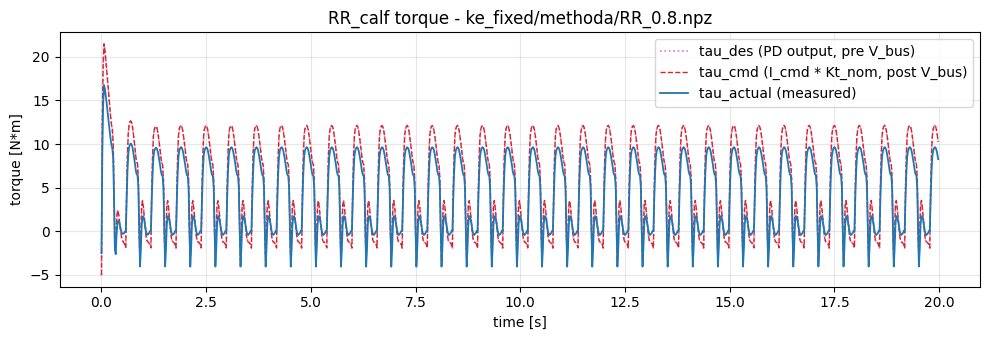

RR_calf V_bus saturation step fraction: 0.0% (max gap: 0.000 N*m)


<Figure size 640x480 with 0 Axes>

In [76]:
import matplotlib.pyplot as plt

# 시간축 만들기: 0, dt, 2·dt, ... (num_steps-1)·dt
t = np.arange(meta["num_steps"]) * meta["dt"]

plt.figure(figsize=(10, 3.5))
plt.plot(t, tau_RR_calf_des,    label="tau_des (PD output, pre V_bus)",       color="tab:pink", ls=":",  lw=1.2)
plt.plot(t, tau_RR_calf_cmd,    label="tau_cmd (I_cmd * Kt_nom, post V_bus)", color="tab:red",  ls="--", lw=1.0)
plt.plot(t, tau_RR_calf_actual, label="tau_actual (measured)",                color="tab:blue", ls="-",  lw=1.3)
plt.xlabel("time [s]")
plt.ylabel("torque [N*m]")
plt.title("RR_calf torque - ke_fixed/methoda/RR_0.8.npz")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# V_bus 포화 빈도 진단: |tau_des - tau_cmd| > 1e-3 인 step 비율
gap = np.abs(tau_RR_calf_des - tau_RR_calf_cmd)
sat_frac = float(np.mean(gap > 1e-3))
print(f"RR_calf V_bus saturation step fraction: {sat_frac:.1%} "
      f"(max gap: {gap.max():.3f} N*m)")

_apply_time_window()


## Healthy vs Fault 겹쳐 보기 — τ_cmd · τ_actual · I_cmd · I_actual

한 관절 (기본 `FL_calf_joint`) 에서 healthy 와 특정 고장 케이스를 **동일 축에 4 선으로** 겹쳐 그립니다 (torque 한 subplot, current 한 subplot).

- **healthy tau_cmd · tau_actual**: 결함이 없으므로 두 곡선이 거의 겹쳐야 함.
- **fault tau_cmd**: controller 는 demag 를 모르므로 healthy 와 **비슷한 수준**의 명령을 냄 (정책 차이 + state 차이로 미세하게 다를 뿐).
- **fault tau_actual**: plant Kt 가 `factor` 배로 줄어 같은 I 로 더 작은 토크 → healthy/fault tau_cmd 와 벌어짐.

전류 쪽도 같은 논리로, `fault I_cmd` 는 PD 가 부족한 토크를 보상하려고 더 큰 값을 내고 (V_bus 한도 내에서), `fault I_actual` 은 그 증가된 지령을 추종합니다.

파일 하나만 바꾸면 (`FAULT_FILE`) 다른 다리·factor 도 똑같이 비교 가능.

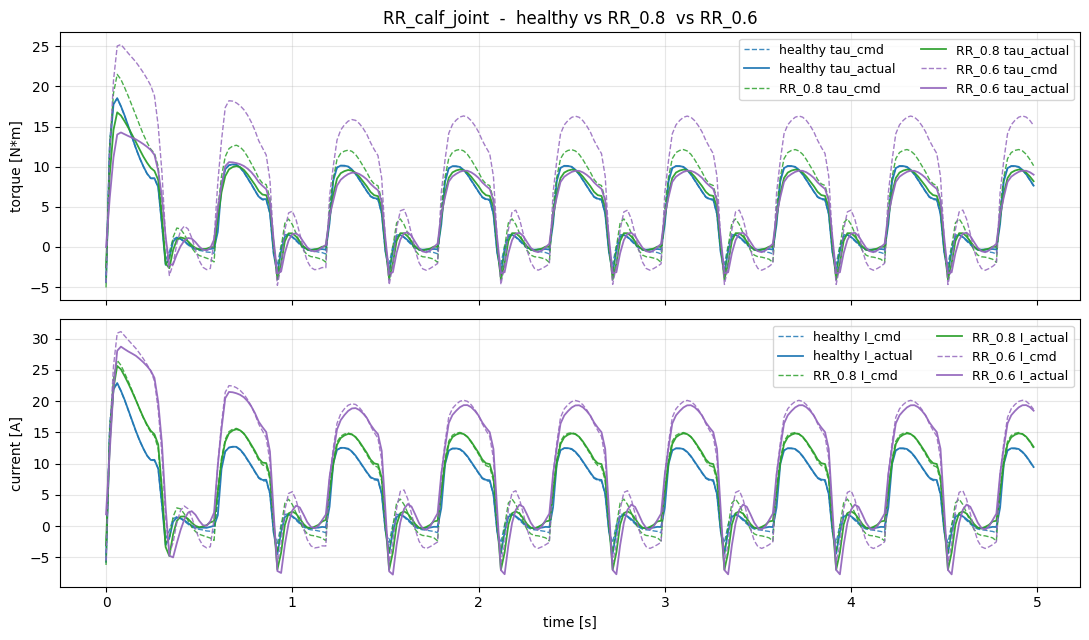


[RR_calf_joint] mean|·| over last 200 steps (steady-state)
  healthy   tau_cmd=  4.301  tau_actual=  4.242  I_cmd=  5.31  I_actual=  5.22
  RR_0.8    tau_cmd=  5.631  tau_actual=  4.312  I_cmd=  6.95  I_actual=  6.68
  measured ratio (tau_actual/tau_cmd in fault) = 0.766  (spec factor = 0.80)


<Figure size 640x480 with 0 Axes>

In [77]:
HEALTHY_FILE = "./data/aplus/healthy.npz"
FAULT_FILE_08   = "./data/aplus/RR_0.8.npz"
FAULT_FILE_06   = "./data/aplus/RR_0.6.npz"
FAULT_FILE_04   = "./data/aplus/RR_0.4.npz"
JOINT        = "RR_calf_joint"

healthy = np.load(HEALTHY_FILE, allow_pickle=True)
FAULT_FILE_08   = np.load(FAULT_FILE_08,   allow_pickle=True)
FAULT_FILE_06   = np.load(FAULT_FILE_06,   allow_pickle=True)
FAULT_FILE_04   = np.load(FAULT_FILE_04,   allow_pickle=True)
h_meta  = json.loads(str(healthy["meta"]))
f_meta_08  = json.loads(str(FAULT_FILE_08["meta"]))
f_meta_06  = json.loads(str(FAULT_FILE_06["meta"]))
f_meta_04  = json.loads(str(FAULT_FILE_04["meta"]))

c_h = h_meta["q_all_joint_names"].index(JOINT)
c_f_08 = f_meta_08["q_all_joint_names"].index(JOINT)
c_f_06 = f_meta_06["q_all_joint_names"].index(JOINT)
c_f_04 = f_meta_04["q_all_joint_names"].index(JOINT)

t_h = np.arange(h_meta["num_steps"]) * h_meta["dt"]
t_f_08 = np.arange(f_meta_08["num_steps"]) * f_meta_08["dt"]
t_f_06 = np.arange(f_meta_06["num_steps"]) * f_meta_06["dt"]
t_f_04 = np.arange(f_meta_04["num_steps"]) * f_meta_04["dt"]

fault_tag_08 = f_meta_08.get("case_tag", f"{f_meta_08['demag_leg']}_{f_meta_08['demag_factor']}")
fault_tag_06 = f_meta_06.get("case_tag", f"{f_meta_06['demag_leg']}_{f_meta_06['demag_factor']}")
fault_tag_04 = f_meta_04.get("case_tag", f"{f_meta_04['demag_leg']}_{f_meta_04['demag_factor']}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# ── torque: healthy(2) + fault(2) = 총 4 선 ──
ax = axes[0]
ax.plot(t_h, healthy["tau_cmd"][:, c_h],    color="tab:blue",    ls="--", lw=1.0, alpha=0.85, label="healthy tau_cmd")
ax.plot(t_h, healthy["tau_actual"][:, c_h], color="tab:blue",   ls="-",  lw=1.3, alpha=0.95, label="healthy tau_actual")
ax.plot(t_f_08, FAULT_FILE_08["tau_cmd"][:, c_f_08],      color="tab:green", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_08} tau_cmd")
ax.plot(t_f_08, FAULT_FILE_08["tau_actual"][:, c_f_08],   color="tab:green",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_08} tau_actual")
ax.plot(t_f_06, FAULT_FILE_06["tau_cmd"][:, c_f_06],      color="tab:purple", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_06} tau_cmd")
ax.plot(t_f_06, FAULT_FILE_06["tau_actual"][:, c_f_06],   color="tab:purple", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_06} tau_actual")
# ax.plot(t_f_04, FAULT_FILE_04["tau_actual"][:, c_f_04],   color="tab:brown",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_04} tau_actual")
ax.set_ylabel("torque [N*m]")
ax.set_title(f"{JOINT}  -  healthy vs {fault_tag_08}  vs {fault_tag_06}")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)

# ── current: healthy(2) + fault(2) = 총 4 선 ──
ax = axes[1]
ax.plot(t_h, healthy["I_cmd"][:, c_h],    color="tab:blue",    ls="--", lw=1.0, alpha=0.85, label="healthy I_cmd")
ax.plot(t_h, healthy["I_actual"][:, c_h], color="tab:blue",   ls="-",  lw=1.3, alpha=0.95, label="healthy I_actual")
ax.plot(t_f_08, FAULT_FILE_08["I_cmd"][:, c_f_08],      color="tab:green", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_08} I_cmd")
ax.plot(t_f_08, FAULT_FILE_08["I_actual"][:, c_f_08],   color="tab:green",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_08} I_actual")
ax.plot(t_f_06, FAULT_FILE_06["I_cmd"][:, c_f_06],      color="tab:purple", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_06} I_cmd")
ax.plot(t_f_06, FAULT_FILE_06["I_actual"][:, c_f_06],   color="tab:purple", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_06} I_actual")
# ax.plot(t_f_04, FAULT_FILE_04["I_actual"][:, c_f_04],   color="tab:brown",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_04} I_actual")
ax.set_ylabel("current [A]")
ax.set_xlabel("time [s]")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)

fig.tight_layout()
plt.show()

# 정상상태 (마지막 200 step) 평균치 요약
def mean_abs_end(arr, col, n=200):
    return float(np.mean(np.abs(arr[-n:, col])))

print(f"\n[{JOINT}] mean|·| over last 200 steps (steady-state)")
print(f"  healthy   tau_cmd={mean_abs_end(healthy['tau_cmd'], c_h):7.3f}  "
      f"tau_actual={mean_abs_end(healthy['tau_actual'], c_h):7.3f}  "
      f"I_cmd={mean_abs_end(healthy['I_cmd'], c_h):6.2f}  "
      f"I_actual={mean_abs_end(healthy['I_actual'], c_h):6.2f}")
print(f"  {fault_tag_08:<9} tau_cmd={mean_abs_end(FAULT_FILE_08['tau_cmd'], c_f_08):7.3f}  "
      f"tau_actual={mean_abs_end(FAULT_FILE_08['tau_actual'], c_f_08):7.3f}  "
      f"I_cmd={mean_abs_end(FAULT_FILE_08['I_cmd'], c_f_08):6.2f}  "
      f"I_actual={mean_abs_end(FAULT_FILE_08['I_actual'], c_f_08):6.2f}")
ratio = mean_abs_end(FAULT_FILE_08['tau_actual'], c_f_08) / max(mean_abs_end(FAULT_FILE_08['tau_cmd'], c_f_08), 1e-9)
print(f"  measured ratio (tau_actual/tau_cmd in fault) = {ratio:.3f}  (spec factor = {f_meta_08['demag_factor']:.2f})")

_apply_time_window()


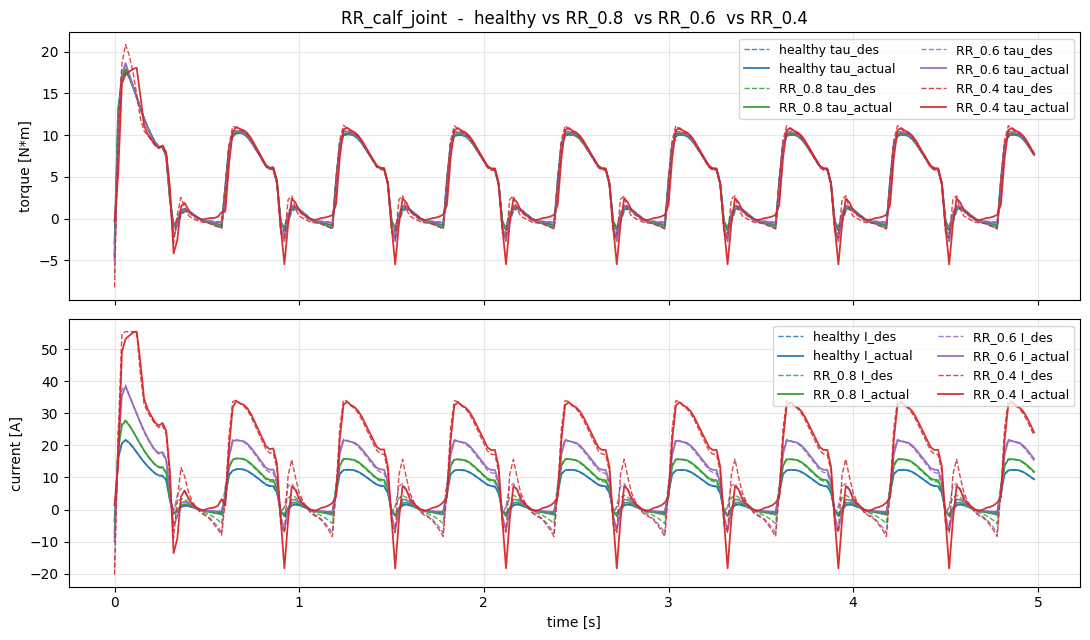


[RR_calf_joint] mean|·| over last 200 steps (steady-state)
  healthy   tau_des=  4.220  tau_actual=  4.263  I_des=  5.21  I_cmd=  5.35  I_actual=  5.24
  RR_0.8    tau_des=  4.257  tau_actual=  4.300  I_des=  5.25  I_cmd=  7.14  I_actual=  6.60
  RR_0.6    tau_des=  4.362  tau_actual=  4.303  I_des=  5.38  I_cmd=  9.85  I_actual=  8.80
  RR_0.4    tau_des=  4.551  tau_actual=  4.375  I_des=  5.62  I_cmd= 14.71  I_actual= 13.61
  measured ratio (tau_actual/tau_des in fault) = 1.010  (spec factor = 0.80)


<Figure size 640x480 with 0 Axes>

In [98]:
HEALTHY_FILE = "./data/aplus_tloop_ki200/healthy.npz"
FAULT_FILE_08   = "./data/aplus_tloop_ki200/RR_0.8.npz"
FAULT_FILE_06   = "./data/aplus_tloop_ki200/RR_0.6.npz"
FAULT_FILE_04   = "./data/aplus_tloop_ki200/RR_0.4.npz"
JOINT        = "RR_calf_joint"

healthy = np.load(HEALTHY_FILE, allow_pickle=True)
FAULT_FILE_08   = np.load(FAULT_FILE_08,   allow_pickle=True)
FAULT_FILE_06   = np.load(FAULT_FILE_06,   allow_pickle=True)
FAULT_FILE_04   = np.load(FAULT_FILE_04,   allow_pickle=True)
h_meta  = json.loads(str(healthy["meta"]))
f_meta_08  = json.loads(str(FAULT_FILE_08["meta"]))
f_meta_06  = json.loads(str(FAULT_FILE_06["meta"]))
f_meta_04  = json.loads(str(FAULT_FILE_04["meta"]))
c_h = h_meta["q_all_joint_names"].index(JOINT)
c_f_08 = f_meta_08["q_all_joint_names"].index(JOINT)
c_f_06 = f_meta_06["q_all_joint_names"].index(JOINT)
c_f_04 = f_meta_04["q_all_joint_names"].index(JOINT)
t_h = np.arange(h_meta["num_steps"]) * h_meta["dt"]
t_f_08 = np.arange(f_meta_08["num_steps"]) * f_meta_08["dt"]
t_f_06 = np.arange(f_meta_06["num_steps"]) * f_meta_06["dt"]
t_f_04 = np.arange(f_meta_04["num_steps"]) * f_meta_04["dt"]
fault_tag_08 = f_meta_08.get("case_tag", f"{f_meta_08['demag_leg']}_{f_meta_08['demag_factor']}")
fault_tag_06 = f_meta_06.get("case_tag", f"{f_meta_06['demag_leg']}_{f_meta_06['demag_factor']}")
fault_tag_04 = f_meta_04.get("case_tag", f"{f_meta_04['demag_leg']}_{f_meta_04['demag_factor']}")
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# ── torque: healthy(2) + fault(2) = 총 4 선 ──
ax = axes[0]
ax.plot(t_h, healthy["tau_des"][:, c_h],    color="tab:blue",    ls="--", lw=1.0, alpha=0.85, label="healthy tau_des")
ax.plot(t_h, healthy["tau_actual"][:, c_h], color="tab:blue",   ls="-",  lw=1.3, alpha=0.95, label="healthy tau_actual")
ax.plot(t_f_08, FAULT_FILE_08["tau_des"][:, c_f_08],      color="tab:green", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_08} tau_des")
ax.plot(t_f_08, FAULT_FILE_08["tau_actual"][:, c_f_08],   color="tab:green",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_08} tau_actual")
ax.plot(t_f_06, FAULT_FILE_06["tau_des"][:, c_f_06],      color="tab:purple", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_06} tau_des")
ax.plot(t_f_06, FAULT_FILE_06["tau_actual"][:, c_f_06],   color="tab:purple", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_06} tau_actual")
ax.plot(t_f_04, FAULT_FILE_04["tau_des"][:, c_f_04],      color="tab:red", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_04} tau_des")
ax.plot(t_f_04, FAULT_FILE_04["tau_actual"][:, c_f_04],   color="tab:red", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_04} tau_actual")
ax.set_ylabel("torque [N*m]")
ax.set_title(f"{JOINT}  -  healthy vs {fault_tag_08}  vs {fault_tag_06}  vs {fault_tag_04}")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)

# ── current: healthy(2) + fault(2) = 총 4 선 ──
ax = axes[1]
ax.plot(t_h, healthy["I_cmd"][:, c_h],    color="tab:blue",    ls="--", lw=1.0, alpha=0.85, label="healthy I_des")
ax.plot(t_h, healthy["I_actual"][:, c_h], color="tab:blue",   ls="-",  lw=1.3, alpha=0.95, label="healthy I_actual")
ax.plot(t_f_08, FAULT_FILE_08["I_cmd"][:, c_f_08],      color="tab:green", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_08} I_des")
ax.plot(t_f_08, FAULT_FILE_08["I_actual"][:, c_f_08],   color="tab:green",  ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_08} I_actual")
ax.plot(t_f_06, FAULT_FILE_06["I_cmd"][:, c_f_06],      color="tab:purple", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_06} I_des")
ax.plot(t_f_06, FAULT_FILE_06["I_actual"][:, c_f_06],   color="tab:purple", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_06} I_actual")
ax.plot(t_f_04, FAULT_FILE_04["I_cmd"][:, c_f_04],      color="tab:red", ls="--", lw=1.0, alpha=0.85, label=f"{fault_tag_04} I_des")
ax.plot(t_f_04, FAULT_FILE_04["I_actual"][:, c_f_04],   color="tab:red", ls="-",  lw=1.3, alpha=0.95, label=f"{fault_tag_04} I_actual")
ax.set_ylabel("current [A]")
ax.set_xlabel("time [s]")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)

fig.tight_layout()
plt.show()

# 정상상태 (마지막 200 step) 평균치 요약
def mean_abs_end(arr, col, n=200):
    return float(np.mean(np.abs(arr[-n:, col])))

print(f"\n[{JOINT}] mean|·| over last 200 steps (steady-state)")
print(f"  healthy   tau_des={mean_abs_end(healthy['tau_des'], c_h):7.3f}  "
      f"tau_actual={mean_abs_end(healthy['tau_actual'], c_h):7.3f}  "
      f"I_des={mean_abs_end(healthy['I_des'], c_h):6.2f}  "
      f"I_cmd={mean_abs_end(healthy['I_cmd'], c_h):6.2f}  "
      f"I_actual={mean_abs_end(healthy['I_actual'], c_h):6.2f}")
print(f"  {fault_tag_08:<9} tau_des={mean_abs_end(FAULT_FILE_08['tau_des'], c_f_08):7.3f}  "
      f"tau_actual={mean_abs_end(FAULT_FILE_08['tau_actual'], c_f_08):7.3f}  "
      f"I_des={mean_abs_end(FAULT_FILE_08['I_des'], c_f_08):6.2f}  "
      f"I_cmd={mean_abs_end(FAULT_FILE_08['I_cmd'], c_f_08):6.2f}  "
      f"I_actual={mean_abs_end(FAULT_FILE_08['I_actual'], c_f_08):6.2f}")
print(f"  {fault_tag_06:<9} tau_des={mean_abs_end(FAULT_FILE_06['tau_des'], c_f_06):7.3f}  "
      f"tau_actual={mean_abs_end(FAULT_FILE_06['tau_actual'], c_f_06):7.3f}  "
      f"I_des={mean_abs_end(FAULT_FILE_06['I_des'], c_f_06):6.2f}  "
      f"I_cmd={mean_abs_end(FAULT_FILE_06['I_cmd'], c_f_06):6.2f}  "
      f"I_actual={mean_abs_end(FAULT_FILE_06['I_actual'], c_f_06):6.2f}")
print(f"  {fault_tag_04:<9} tau_des={mean_abs_end(FAULT_FILE_04['tau_des'], c_f_04):7.3f}  "
      f"tau_actual={mean_abs_end(FAULT_FILE_04['tau_actual'], c_f_04):7.3f}  "
      f"I_des={mean_abs_end(FAULT_FILE_04['I_des'], c_f_04):6.2f}  "
      f"I_cmd={mean_abs_end(FAULT_FILE_04['I_cmd'], c_f_04):6.2f}  "
      f"I_actual={mean_abs_end(FAULT_FILE_04['I_actual'], c_f_04):6.2f}")
ratio = mean_abs_end(FAULT_FILE_08['tau_actual'], c_f_08) / max(mean_abs_end(FAULT_FILE_08['tau_des'], c_f_08), 1e-9)
print(f"  measured ratio (tau_actual/tau_des in fault) = {ratio:.3f}  (spec factor = {f_meta_08['demag_factor']:.2f})")

_apply_time_window()


### q_des 비교 — healthy vs fault

정책이 demag 를 모르는 채로 **같은 state 에 반응** 해도, 다리가 약해지면 state 가 달라져 `q_des` 자체가 미세하게 달라질 수 있습니다. healthy 와 fault 의 `q_des` 를 겹쳐 보면 **정책이 고장에 얼마나 반응하고 있는지** 를 볼 수 있습니다.

- 거의 겹치면: 정책은 demag 를 거의 눈치 못 챘고, state 변화도 작음.
- 눈에 띄게 갈라지면: state 변화가 정책 입력에 반영돼 `q_des` 자체가 다른 궤적을 만들어냄.

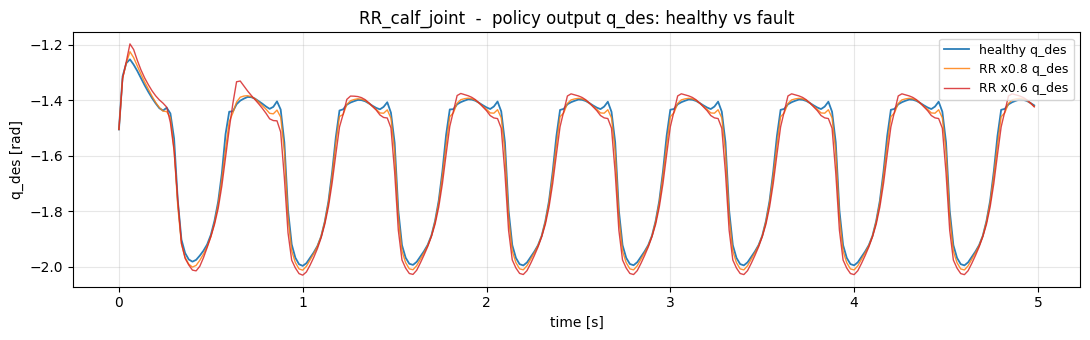


[RR_calf_joint] RMS(fault q_des - healthy q_des), steady-state
  RR x0.8     RMS=0.04070 rad  max|diff|=0.07044 rad
  RR x0.6     RMS=0.11082 rad  max|diff|=0.19526 rad


<Figure size 640x480 with 0 Axes>

In [79]:
# healthy 와 fault case 의 q_all 겹쳐보기
# (위 셀에서 쓴 파일·관절 변수를 그대로 재사용해도 되지만 self-contained 하게 다시 로드)
HEALTHY = "./data/aplus/healthy.npz"
FAULTS  = [
    ("RR x0.8", "./data/aplus/RR_0.8.npz", "tab:orange"),
    ("RR x0.6", "./data/aplus/RR_0.6.npz", "tab:red"),
    # ("RR x0.4", "./data/aplus/RR_0.4.npz", "tab:purple"),
]
JOINT_NAME = "RR_calf_joint"

h  = np.load(HEALTHY, allow_pickle=True)
hm = json.loads(str(h["meta"]))
c  = hm["q_all_joint_names"].index(JOINT_NAME)
t  = np.arange(hm["num_steps"]) * hm["dt"]

plt.figure(figsize=(11, 3.5))

# healthy q_des 를 기준선으로
plt.plot(t, h["q_des"][:, c], color="tab:blue", lw=1.3, alpha=0.95,
         label="healthy q_des")

# 각 fault case q_des 겹치기
for label, path, color in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    tf = np.arange(m["num_steps"]) * m["dt"]
    plt.plot(tf, d["q_des"][:, cf], color=color, lw=1.0,  alpha=0.85,
             label=f"{label} q_des")

plt.xlabel("time [s]")
plt.ylabel("q_des [rad]")
plt.title(f"{JOINT_NAME}  -  policy output q_des: healthy vs fault")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# 정량 차이: healthy 대비 RMS difference (정상상태)
TRANSIENT_S = 1.0
k0 = int(TRANSIENT_S / hm["dt"])
print(f"\n[{JOINT_NAME}] RMS(fault q_des - healthy q_des), steady-state")
for label, path, _ in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    diff = d["q_all"][k0:, cf] - h["q_all"][k0:, c]
    print(f"  {label:<10}  RMS={np.sqrt(np.mean(diff**2)):.5f} rad  "
          f"max|diff|={np.max(np.abs(diff)):.5f} rad")

_apply_time_window()


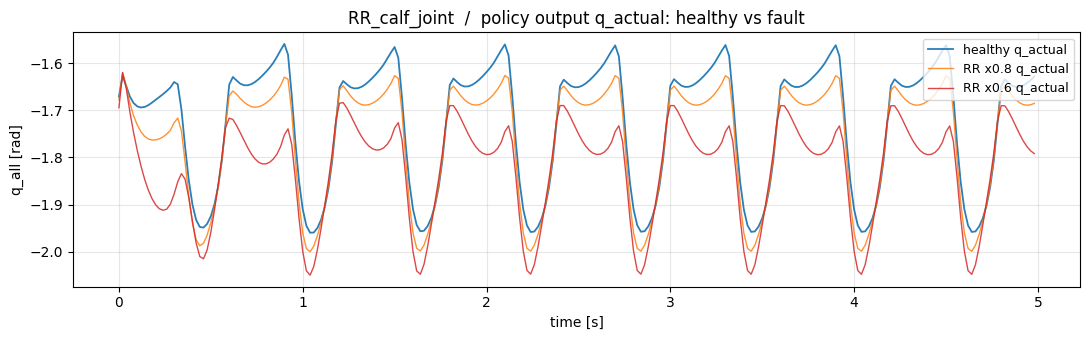


[RR_calf_joint] RMS(fault q_actual - healthy q_actual), steady-state
  RR x0.8     RMS=0.04070 rad  max|diff|=0.07044 rad
  RR x0.6     RMS=0.11082 rad  max|diff|=0.19526 rad


<Figure size 640x480 with 0 Axes>

In [80]:
# healthy 와 fault case 의 q_all 겹쳐보기
# (위 셀에서 쓴 파일·관절 변수를 그대로 재사용해도 되지만 self-contained 하게 다시 로드)
HEALTHY = "./data/aplus/healthy.npz"
FAULTS  = [
    ("RR x0.8", "./data/aplus/RR_0.8.npz", "tab:orange"),
    ("RR x0.6", "./data/aplus/RR_0.6.npz", "tab:red"),
    # ("RR x0.4", "./data/aplus/RR_0.4.npz", "tab:purple"),
]
JOINT_NAME = "RR_calf_joint"

h  = np.load(HEALTHY, allow_pickle=True)
hm = json.loads(str(h["meta"]))
c  = hm["q_all_joint_names"].index(JOINT_NAME)
t  = np.arange(hm["num_steps"]) * hm["dt"]

plt.figure(figsize=(11, 3.5))

# healthy q_all 를 기준선으로
plt.plot(t, h["q_all"][:, c], color="tab:blue", lw=1.3, alpha=0.95,
         label="healthy q_actual")

# 각 fault case q_all 겹치기
for label, path, color in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    tf = np.arange(m["num_steps"]) * m["dt"]
    plt.plot(tf, d["q_all"][:, cf], color=color, lw=1.0, alpha=0.85,
             label=f"{label} q_actual")

plt.xlabel("time [s]")
plt.ylabel("q_all [rad]")
plt.title(f"{JOINT_NAME}  /  policy output q_actual: healthy vs fault")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# 정량 차이: healthy 대비 RMS difference (정상상태)
TRANSIENT_S = 1.0
k0 = int(TRANSIENT_S / hm["dt"])
print(f"\n[{JOINT_NAME}] RMS(fault q_actual - healthy q_actual), steady-state")
for label, path, _ in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    diff = d["q_all"][k0:, cf] - h["q_all"][k0:, c]
    print(f"  {label:<10}  RMS={np.sqrt(np.mean(diff**2)):.5f} rad  "
          f"max|diff|={np.max(np.abs(diff)):.5f} rad")

_apply_time_window()


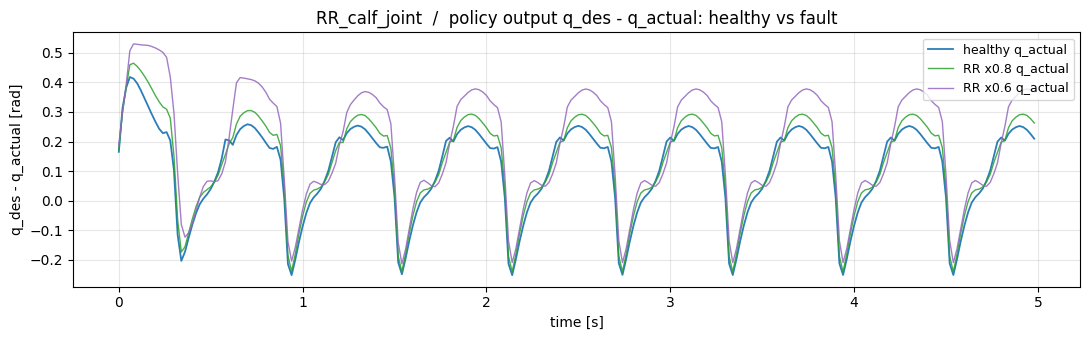


[RR_calf_joint] RMS(fault q_des - q_actual - healthy q_des - q_actual), steady-state
  RR x0.8     RMS=0.03316 rad  max|diff|=0.05407 rad
  RR x0.6     RMS=0.09457 rad  max|diff|=0.16303 rad


<Figure size 640x480 with 0 Axes>

In [94]:
# healthy 와 fault case 의 q_des - q_all 겹쳐보기
# (위 셀에서 쓴 파일·관절 변수를 그대로 재사용해도 되지만 self-contained 하게 다시 로드)
HEALTHY = "./data/aplus/healthy.npz"
FAULTS  = [
    ("RR x0.8", "./data/aplus/RR_0.8.npz", "tab:green"),
    ("RR x0.6", "./data/aplus/RR_0.6.npz", "tab:purple"),
    # ("RR x0.4", "./data/aplus/RR_0.4.npz", "tab:purple"),
]
JOINT_NAME = "RR_calf_joint"

h  = np.load(HEALTHY, allow_pickle=True)
hm = json.loads(str(h["meta"]))
c  = hm["q_all_joint_names"].index(JOINT_NAME)
t  = np.arange(hm["num_steps"]) * hm["dt"]

plt.figure(figsize=(11, 3.5))

# healthy q_all 를 기준선으로
plt.plot(t, h["q_des"][:, c]-h["q_all"][:, c], color="tab:blue", lw=1.3, alpha=0.95,
         label="healthy q_actual")

# 각 fault case q_all 겹치기
for label, path, color in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    tf = np.arange(m["num_steps"]) * m["dt"]
    plt.plot(tf, d["q_des"][:, cf]-d["q_all"][:, cf], color=color, lw=1.0,  alpha=0.85,
             label=f"{label} q_actual")

plt.xlabel("time [s]")
plt.ylabel("q_des - q_actual [rad]")
plt.title(f"{JOINT_NAME}  /  policy output q_des - q_actual: healthy vs fault")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# 정량 차이: healthy 대비 RMS difference (정상상태)
TRANSIENT_S = 1.0
k0 = int(TRANSIENT_S / hm["dt"])
print(f"\n[{JOINT_NAME}] RMS(fault q_des - q_actual - healthy q_des - q_actual), steady-state")
for label, path, _ in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    diff = (d["q_des"][k0:, cf] - d["q_all"][k0:, cf]) - (h["q_des"][k0:, c] - h["q_all"][k0:, c])
    print(f"  {label:<10}  RMS={np.sqrt(np.mean(diff**2)):.5f} rad  "
          f"max|diff|={np.max(np.abs(diff)):.5f} rad")

_apply_time_window()


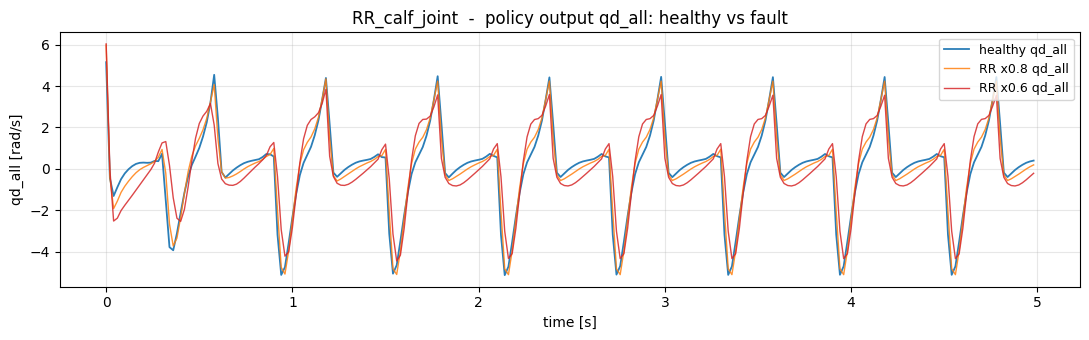


[RR_calf_joint] RMS(fault qd_all - healthy qd_all), steady-state
  RR x0.8     RMS=0.38368 rad/s  max|diff|=1.13015 rad/s
  RR x0.6     RMS=0.95912 rad/s  max|diff|=2.81370 rad/s


<Figure size 640x480 with 0 Axes>

In [82]:
# healthy 와 fault case 의 qd_all 겹쳐보기
# (위 셀에서 쓴 파일·관절 변수를 그대로 재사용해도 되지만 self-contained 하게 다시 로드)
HEALTHY = "./data/aplus/healthy.npz"
FAULTS  = [
    ("RR x0.8", "./data/aplus/RR_0.8.npz", "tab:orange"),
    ("RR x0.6", "./data/aplus/RR_0.6.npz", "tab:red"),
    # ("RR x0.4", "./data/aplus/RR_0.4.npz", "tab:purple"),
]
JOINT_NAME = "RR_calf_joint"

h  = np.load(HEALTHY, allow_pickle=True)
hm = json.loads(str(h["meta"]))
c  = hm["q_all_joint_names"].index(JOINT_NAME)
t  = np.arange(hm["num_steps"]) * hm["dt"]

plt.figure(figsize=(11, 3.5))

# healthy qd_all 를 기준선으로
plt.plot(t, h["qd_all"][:, c], color="tab:blue", lw=1.3, alpha=0.95,
         label="healthy qd_all")

# 각 fault case qd_all 겹치기
for label, path, color in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    tf = np.arange(m["num_steps"]) * m["dt"]
    plt.plot(tf, d["qd_all"][:, cf], color=color, lw=1.0, alpha=0.85,
             label=f"{label} qd_all")

plt.xlabel("time [s]")
plt.ylabel("qd_all [rad/s]")
plt.title(f"{JOINT_NAME}  -  policy output qd_all: healthy vs fault")
plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# 정량 차이: healthy 대비 RMS difference (정상상태)
TRANSIENT_S = 1.0
k0 = int(TRANSIENT_S / hm["dt"])
print(f"\n[{JOINT_NAME}] RMS(fault qd_all - healthy qd_all), steady-state")
for label, path, _ in FAULTS:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    cf = m["q_all_joint_names"].index(JOINT_NAME)
    diff = d["qd_all"][k0:, cf] - h["qd_all"][k0:, c]
    print(f"  {label:<10}  RMS={np.sqrt(np.mean(diff**2)):.5f} rad/s  "
          f"max|diff|={np.max(np.abs(diff)):.5f} rad/s")

_apply_time_window()


### 순간값 관계 — tau_actual vs e_q (1/(α·Kp) 직선성)

시계열이 아니라 **순간값 산점도** 로 `tau_actual ≈ α·[Kp·e_q + Kd·e_qd]` 를 확인.
`qd_des ≈ qd_actual` 이라 Kd 항 기여가 작다고 가정하면:

```
e_q ≈ tau_actual / (α · Kp)
```

즉 x=`tau_actual`, y=`q_des - q_all` 산점도의 **기울기가 1/(α·Kp)** 이어야 함.
(`q_actual` 은 스키마상 `q_all`. Kp, Kd 는 `go2_constants.py` — calf 관절 Kp=40, Kd=2.)

[healthy (α=1.0)]
  e_q  peak: 0.253 rad,    Kp*e_q  peak: 10.12 N*m
  e_qd peak: 5.133 rad/s, Kd*e_qd peak: 10.27 N*m
  ratio (Kd*e_qd) / (Kp*e_q) = 101.4 %
[RR x0.8]
  e_q  peak: 0.293 rad,    Kp*e_q  peak: 11.70 N*m
  e_qd peak: 5.109 rad/s, Kd*e_qd peak: 10.22 N*m
  ratio (Kd*e_qd) / (Kp*e_q) = 87.3 %
[RR x0.6]
  e_q  peak: 0.378 rad,    Kp*e_q  peak: 15.12 N*m
  e_qd peak: 4.335 rad/s, Kd*e_qd peak: 8.67 N*m
  ratio (Kd*e_qd) / (Kp*e_q) = 57.3 %


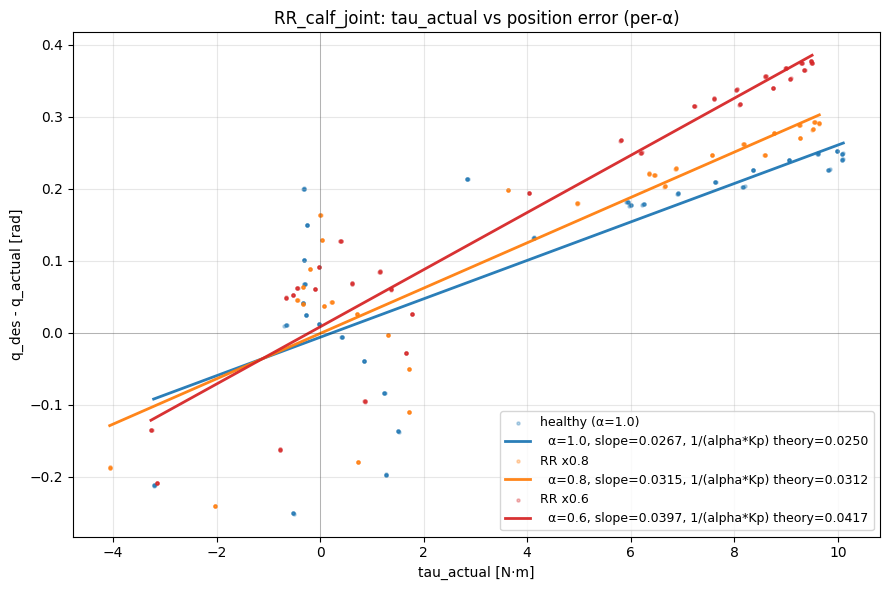

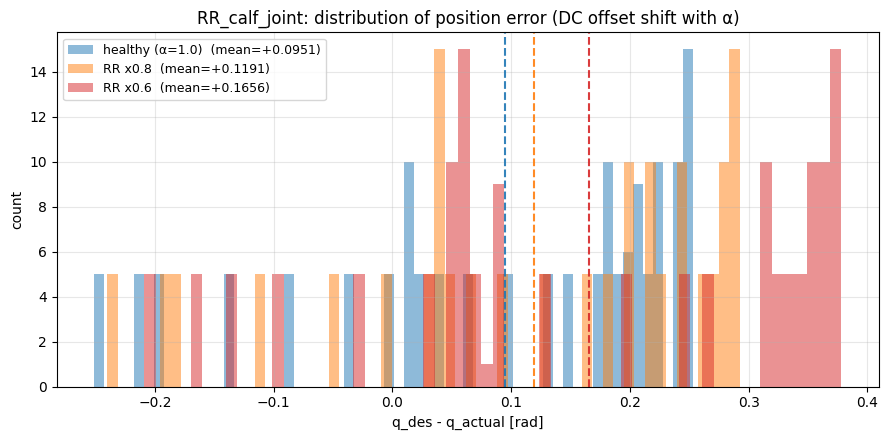

<Figure size 640x480 with 0 Axes>

In [ ]:
# tau_actual vs position error — 순간값 관계로 1/(α·Kp) 직선성 확인
# 이론: tau_actual ≈ α * [Kp * e_q + Kd * e_qd]  (Kd·e_qd 기여는 작다고 가정)
# ⇒ e_q ≈ tau_actual / (α · Kp)  → 기울기 1/(α·Kp) 인 직선

CASES = [
    ("healthy (α=1.0)", "./data/aplus/healthy.npz", 1.0, "tab:blue"),
    ("RR x0.8",         "./data/aplus/RR_0.8.npz",  0.8, "tab:orange"),
    ("RR x0.6",         "./data/aplus/RR_0.6.npz",  0.6, "tab:red"),
]
JOINT_NAME = "RR_calf_joint"
T_SKIP_S   = 2.0     # 초기 과도구간 skip
KP         = 40.0    # calf 관절 (go2_constants.py line 64)
KD         = 2.0

# ── (1) tau_actual vs e_q 산점도 + 선형회귀 ─────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(9, 6))

for label, p, alpha_f, color in CASES:
    d = np.load(p, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT_NAME)
    k0 = int(T_SKIP_S / m["dt"])

    tau_a = d["tau_actual"][k0:, c]
    e_q   = d["q_des"][k0:, c] - d["q_all"][k0:, c]
    # PD law uses -Kd*qd (qd_des=0), so e_qd = qd_des - qd_actual = -qd_all
    e_qd  = -d["qd_all"][k0:, c]

    # Kd*e_qd 항 기여가 작다는 가정 점검 (Kp*e_q 대비 peak 비율)
    e_q_peak  = float(np.abs(e_q).max())
    e_qd_peak = float(np.abs(e_qd).max())
    print(f"[{label}]")
    print(f"  e_q  peak: {e_q_peak:.3f} rad,    Kp*e_q  peak: {KP*e_q_peak:.2f} N*m")
    print(f"  e_qd peak: {e_qd_peak:.3f} rad/s, Kd*e_qd peak: {KD*e_qd_peak:.2f} N*m")
    print(f"  ratio (Kd*e_qd) / (Kp*e_q) = {(KD*e_qd_peak) / (KP*e_q_peak) * 100:.1f} %")

    # 산점 (반투명, 작은 점)
    ax1.scatter(tau_a, e_q, s=5, alpha=0.3, color=color, label=label)

    # 선형회귀
    slope, intercept = np.polyfit(tau_a, e_q, deg=1)
    x_line = np.linspace(tau_a.min(), tau_a.max(), 100)
    theory = 1.0 / (alpha_f * KP)
    ax1.plot(
        x_line, slope * x_line + intercept,
        color=color, lw=2.0, alpha=0.95,
        label=f"  α={alpha_f:.1f}, slope={slope:.4f}, 1/(alpha*Kp) theory={theory:.4f}",
    )

ax1.axhline(0, color="k", lw=0.4, alpha=0.4)
ax1.axvline(0, color="k", lw=0.4, alpha=0.4)
ax1.set_xlabel("tau_actual [N·m]")
ax1.set_ylabel("q_des - q_actual [rad]")
ax1.set_title(f"{JOINT_NAME}: tau_actual vs position error (per-α)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="best", fontsize=9)
fig1.tight_layout()

# ── (2) e_q 히스토그램 (DC 오프셋 비교) ─────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4.5))

for label, p, alpha_f, color in CASES:
    d = np.load(p, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT_NAME)
    k0 = int(T_SKIP_S / m["dt"])

    e_q = d["q_des"][k0:, c] - d["q_all"][k0:, c]
    mu  = float(e_q.mean())

    ax2.hist(e_q, bins=60, alpha=0.5, color=color, label=f"{label}  (mean={mu:+.4f})")
    ax2.axvline(mu, color=color, ls="--", lw=1.5, alpha=0.9)

ax2.set_xlabel("q_des - q_actual [rad]")
ax2.set_ylabel("count")
ax2.set_title(f"{JOINT_NAME}: distribution of position error (DC offset shift with α)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="best", fontsize=9)
fig2.tight_layout()


plt.show()

_apply_time_window()


### 2변수 회귀 — tau_actual ~ α·Kp·e_q + α·Kd·e_qd

이전 1변수 회귀 (`tau_actual vs e_q`) 기울기가 `1/(α·Kp)` 이론치와 5% 이내로 맞았음. 그러나 `Kd·|e_qd|` 가 `Kp·|e_q|` 의 50~98% 수준이라 Kd 항이 무시할 수준은 아니었음. 따라서:

- **모델이 정말 맞아서 맞은 건지** (α·Kp, α·Kd 둘 다 이론과 맞으면 OK)
- **공선성 때문에 우연히 맞은 건지** (α·Kp 는 맞고 α·Kd 가 엉뚱하면 공선성)

를 판별하기 위해 **2변수 선형회귀 (절편 없음)** 를 수행하고, 같은 표에 기존 1변수 결과를 병기해 비교.


=== RR_calf_joint: 2-variable regression (no intercept) ===
case         aKp_hat   aKp_th   errKp%    aKd_hat   aKd_th   errKd%      R^2
----------------------------------------------------------------------------
healthy       39.818    40.00    -0.45      1.902     2.00    -4.90   0.9936
RR x0.8       32.012    32.00    +0.04      1.249     1.60   -21.97   0.9969
RR x0.6       24.074    24.00    +0.31      0.738     1.20   -38.53   0.9991

=== RR_calf_joint: 1-var vs 2-var comparison ===
case         1v slope  1v theory  1v err%     2v aKp  2v aKp th  2v err%
------------------------------------------------------------------------
healthy       0.02670    0.02500    +6.79     39.818     40.000    -0.45
RR x0.8       0.03149    0.03125    +0.77     32.012     32.000    +0.04
RR x0.6       0.03970    0.04167    -4.72     24.074     24.000    +0.31


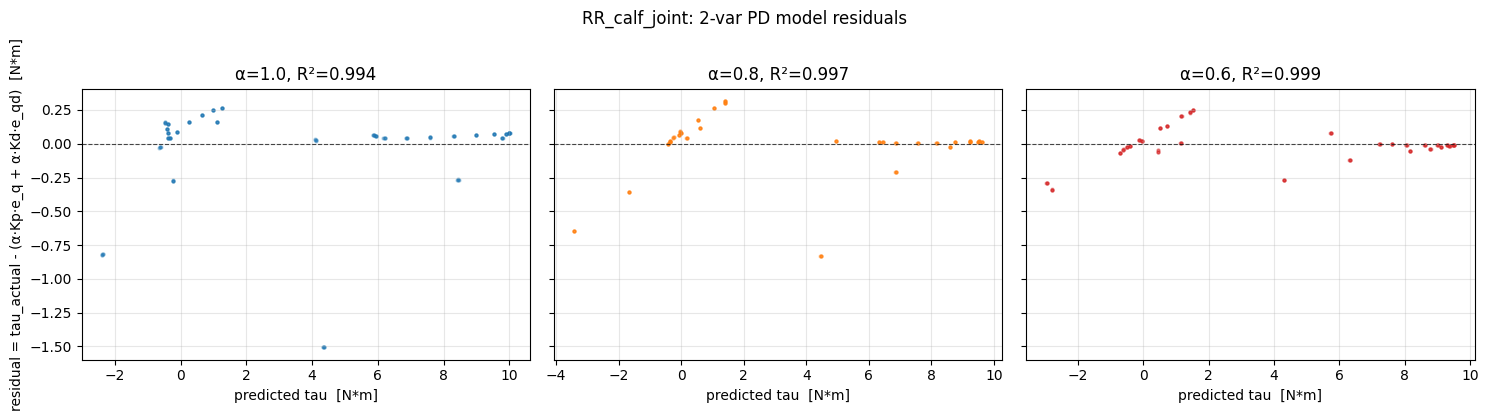

<Figure size 640x480 with 0 Axes>

In [84]:
# 2-var regression: tau_actual ~ α·Kp·e_q + α·Kd·e_qd  (no intercept)
# e_qd = qd_des - qd_actual = -qd_all  (PD law: -Kd·qd → qd_des=0)
#
# 판별 가이드:
#   둘 다 이론 10% 이내  → 모델 정확 (해석 2: 1-var 성공은 peak 분리 덕분)
#   α·Kp 만 맞음         → e_q/e_qd 공선성 (해석 1: 1-var 는 우연히 맞음)
#   둘 다 엉뚱함          → 모델 자체 재검토 (관성/중력 보상 누락 가능)

CASES_2V = [
    ("healthy", "./data/aplus/healthy.npz", 1.0, "tab:blue"),
    ("RR x0.8", "./data/aplus/RR_0.8.npz",  0.8, "tab:orange"),
    ("RR x0.6", "./data/aplus/RR_0.6.npz",  0.6, "tab:red"),
]
JOINT_NAME = "RR_calf_joint"
T_SKIP_S   = 2.0
KP         = 40.0    # calf (go2_constants.py line 64)
KD         = 2.0


fig_r, axes_r = plt.subplots(1, len(CASES_2V), figsize=(15, 4), sharey=True)

rows = []
for ax_r, (label, p, alpha_f, color) in zip(axes_r, CASES_2V):
    d = np.load(p, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT_NAME)
    k0 = int(T_SKIP_S / m["dt"])

    tau_a = d["tau_actual"][k0:, c]
    e_q   = d["q_des"][k0:, c] - d["q_all"][k0:, c]
    e_qd  = -d["qd_all"][k0:, c]     # PD law: qd_des=0 → e_qd = -qd_all

    # ── 2-var regression (no intercept) ────────────────────────────────────
    X2 = np.column_stack([e_q, e_qd])
    coef2, *_ = np.linalg.lstsq(X2, tau_a, rcond=None)
    aKp_hat2, aKd_hat2 = float(coef2[0]), float(coef2[1])

    y_pred = X2 @ coef2
    ss_res = float(np.sum((tau_a - y_pred) ** 2))
    ss_tot = float(np.sum((tau_a - tau_a.mean()) ** 2))   # 표준 R² (centered)
    r2     = 1.0 - ss_res / ss_tot

    # ── 1-var regression: e_q ~ tau_a  (cell 16 과 동일 방향, with intercept)
    slope1, intercept1 = np.polyfit(tau_a, e_q, deg=1)    # slope ≈ 1/(α·Kp)

    # ── 이론치 & 오차 ────────────────────────────────────────────────────
    aKp_th = alpha_f * KP
    aKd_th = alpha_f * KD
    err_Kp = (aKp_hat2 - aKp_th) / aKp_th * 100
    err_Kd = (aKd_hat2 - aKd_th) / aKd_th * 100
    slope1_th = 1.0 / aKp_th

    rows.append((label, alpha_f,
                 aKp_hat2, aKp_th, err_Kp,
                 aKd_hat2, aKd_th, err_Kd,
                 r2,
                 slope1, slope1_th))

    # ── 잔차 플롯 ────────────────────────────────────────────────────────
    residual = tau_a - y_pred
    ax_r.scatter(y_pred, residual, s=4, alpha=0.3, color=color)
    ax_r.axhline(0, color="k", ls="--", lw=0.8, alpha=0.7)
    ax_r.set_xlabel("predicted tau  [N*m]")
    ax_r.set_title(f"α={alpha_f:.1f}, R²={r2:.3f}")
    ax_r.grid(True, alpha=0.3)

axes_r[0].set_ylabel("residual = tau_actual - (α·Kp·e_q + α·Kd·e_qd)  [N*m]")
fig_r.suptitle(f"{JOINT_NAME}: 2-var PD model residuals", y=1.02)
fig_r.tight_layout()


# ── 표 1: 2-var 계수 vs 이론 ───────────────────────────────────────────────
print(f"\n=== {JOINT_NAME}: 2-variable regression (no intercept) ===")
h1 = (f"{'case':<10} {'aKp_hat':>9} {'aKp_th':>8} {'errKp%':>8}  "
      f"{'aKd_hat':>9} {'aKd_th':>8} {'errKd%':>8}  {'R^2':>7}")
print(h1)
print("-" * len(h1))
for (lbl, af, aKp_h, aKp_t, eKp, aKd_h, aKd_t, eKd, r2, *_rest) in rows:
    print(f"{lbl:<10} {aKp_h:>9.3f} {aKp_t:>8.2f} {eKp:>+8.2f}  "
          f"{aKd_h:>9.3f} {aKd_t:>8.2f} {eKd:>+8.2f}  {r2:>7.4f}")

# ── 표 2: 1-var vs 2-var 비교 ─────────────────────────────────────────────
print(f"\n=== {JOINT_NAME}: 1-var vs 2-var comparison ===")
h2 = (f"{'case':<10} {'1v slope':>10} {'1v theory':>10} {'1v err%':>8}  "
      f"{'2v aKp':>9} {'2v aKp th':>10} {'2v err%':>8}")
print(h2)
print("-" * len(h2))
for (lbl, af, aKp_h, aKp_t, eKp, _kd_h, _kd_t, _ekd, r2, s1, s1_th) in rows:
    e1 = (s1 - s1_th) / s1_th * 100
    print(f"{lbl:<10} {s1:>10.5f} {s1_th:>10.5f} {e1:>+8.2f}  "
          f"{aKp_h:>9.3f} {aKp_t:>10.3f} {eKp:>+8.2f}")

plt.show()

_apply_time_window()


## Kt 데이터 역추정 — 가장 직접적인 고장 증거

`tau_actual = Kt_plant · gr · I_actual` 이므로 **τ_actual vs I_actual 산점도의 기울기 = `Kt · gr`** 입니다. 세 조건 (healthy=×1.0 / FL×0.8 / FL×0.6) 각각에 대해 원점을 지나는 직선으로 회귀하면, 기울기 비율이 **1 : 0.8 : 0.6** 과 일치해야 합니다.

- 일치하면: demag 주입이 `gainprm` (plant Kt) 에 의도한 만큼 반영된다는 직접 증거.
- 크게 어긋나면: actuator 모델 구현 버그나 전압 포화·filter transient 같은 다른 효과의 오염 가능성.

과도기(0~1 s) 는 버리고 정상상태만 회귀에 사용합니다. FL_calf_joint 기준 예시."


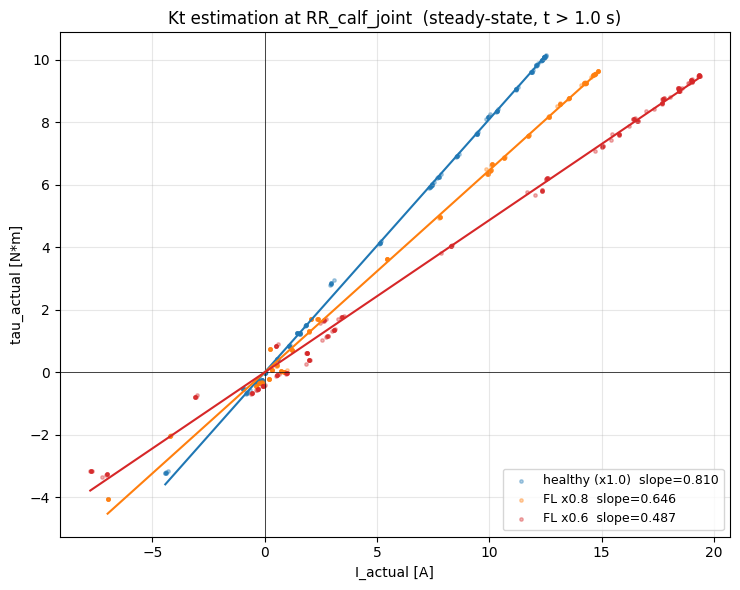


case                slope   slope/healthy   expected factor      err
healthy (x1.0)     0.8096          1.0000              1.00  +0.0000
FL x0.8            0.6463          0.7983              0.80  -0.0017
FL x0.6            0.4868          0.6012              0.60  +0.0012


<Figure size 640x480 with 0 Axes>

In [85]:
# 세 조건의 파일 목록 (label, 파일 경로, 기대 factor, 색)
CASES = [
    ("healthy (x1.0)", "./data/aplus/healthy.npz", 1.0, "tab:blue"),
    ("FL x0.8",        "./data/aplus/RR_0.8.npz",  0.8, "tab:orange"),
    ("FL x0.6",        "./data/aplus/RR_0.6.npz",  0.6, "tab:red"),
]
JOINT       = "RR_calf_joint"
TRANSIENT_S = 1.0   # 처음 1초 (과도기) 는 회귀에서 제외

# 각 파일을 열고 정상상태 구간의 (I_actual, tau_actual) 만 수집
slopes = []   # 각 케이스의 회귀 기울기 저장
plt.figure(figsize=(7.5, 6))
plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)

for label, path, factor, color in CASES:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    c  = m["q_all_joint_names"].index(JOINT)
    k0 = int(TRANSIENT_S / m["dt"])   # 과도기 컷 인덱스 (1 s → 50 step)

    I   = d["I_actual"][k0:, c]
    tau = d["tau_actual"][k0:, c]

    # 원점 지나는 1차 회귀: tau ≈ slope · I
    #   최소제곱해 slope = Σ(tau·I) / Σ(I²)
    slope = float(np.sum(tau * I) / np.sum(I ** 2))
    slopes.append(slope)

    # 산점도 + 회귀 직선
    plt.scatter(I, tau, s=6, color=color, alpha=0.35,
                label=f"{label}  slope={slope:.3f}")
    I_line = np.linspace(I.min(), I.max(), 100)
    plt.plot(I_line, slope * I_line, color=color, lw=1.5)

plt.xlabel("I_actual [A]")
plt.ylabel("tau_actual [N*m]")
plt.title(f"Kt estimation at {JOINT}  (steady-state, t > {TRANSIENT_S} s)")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# 기울기 비율: healthy 를 기준 (1.0) 으로 정규화해서 factor 와 비교
base = slopes[0]
print(f"\n{'case':<16} {'slope':>8} {'slope/healthy':>15} {'expected factor':>17} {'err':>8}")
for (label, _, factor, _), s in zip(CASES, slopes):
    rel = s / base
    err = rel - factor
    print(f"{label:<16} {s:>8.4f} {rel:>15.4f} {factor:>17.2f} {err:>+8.4f}")

_apply_time_window()


## V_bus 클리핑 — 고장이 실제로 성능을 해치기 시작하는 지점

두 가지 지표를 시간축 위에 같이 봅니다:

1. **`tau_des - tau_cmd`**: PD 지령 (pre V_bus) 과 전류 지령 (post V_bus) 의 차이.
   - 비포화 구간: 0 (두 값 완전 일치).
   - 포화 구간: 0 이 아닌 값 — V_bus 가 원하는 전압을 꺾은 크기.

2. **`I_des - I_actual`**: 컨트롤러가 원하는 전류 vs 실제 코일 전류 (filterexact ODE 적분값) 의 추종 오차.
   - 평상시: 거의 0 (전기 시정수 `τ_e = L/R` 이 서브-ms, policy dt 20 ms 안에서 충분히 수렴).
   - 포화 구간: `I_actual` 이 `I_des` 를 못 따라감 → 오차 증가.

**해석 포인트 — 0.6 조건의 clipping 빈도·지속시간**:
- *드물고 짧다*: 컨트롤러가 전류를 더 밀어서 아직 토크 보상 중 → τ_actual 은 τ_cmd 를 여전히 잘 따라감.
- *잦고 길어진다*: V_bus 가 부족해 실제 전류가 지령보다 덜 올라감 → τ_actual 이 τ_cmd 를 벗어나기 시작하는 경계.

이 경계를 잡아두면 이후 factor 0.4 / 0.3 같은 심한 고장 시뮬 해석이 깔끔해집니다 (clipping 기여분을 별도 계정할 수 있음).

case               sat %   max |gap|   longest sat   mean |I_err|  max |I_err|
------------------------------------------------------------------------------
healthy (x1.0)    99.6%       2.182       4.580 s         0.148 A       1.630 A
RR x0.8          100.0%       5.060       5.000 s         1.533 A       5.736 A
RR x0.6          100.0%      13.114       5.000 s         4.005 A      15.712 A
RR x0.4          100.0%      30.109       5.000 s         9.457 A      37.161 A


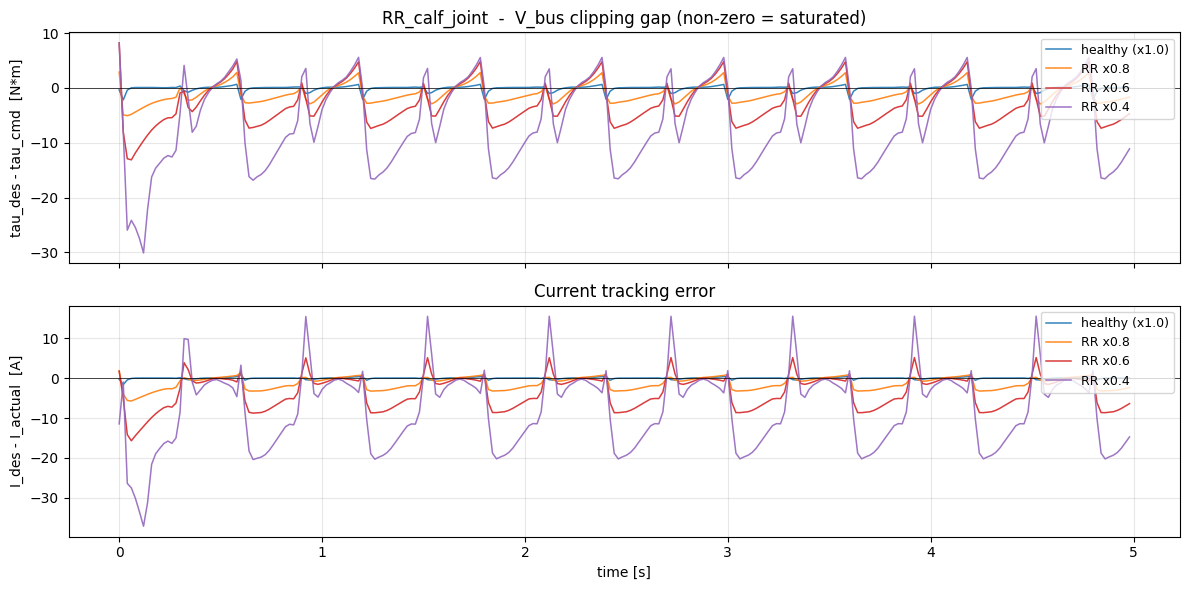

<Figure size 640x480 with 0 Axes>

In [86]:
# 비교할 조건들 (healthy + FL 0.8 / 0.6)
CASES = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]
JOINT   = "RR_calf_joint"
SAT_EPS = 1e-3   # |tau_des - tau_cmd| 가 이 이상이면 "V_bus 포화 중" 으로 판정 [N*m]


def longest_run_steps(mask):
    """True 가 연속으로 이어진 최대 길이 (step 개수) — 포화 지속시간 계산용."""
    best = cur = 0
    for flag in mask:
        if flag:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best


# 2 x 1 subplot: 위 = V_bus 포화 gap, 아래 = 전류 추종 오차
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

print(f"{'case':<16} {'sat %':>7} {'max |gap|':>11} {'longest sat':>13} "
      f"{'mean |I_err|':>14} {'max |I_err|':>12}")
print("-" * 78)

for label, path, color in CASES:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT)
    t = np.arange(m["num_steps"]) * m["dt"]

    # 시계열 추출
    gap_tau = d["tau_des"][:, c] - d["tau_cmd"][:, c]   # V_bus 포화 gap
    err_I   = d["I_des"][:, c]   - d["I_actual"][:, c]  # 전류 추종 오차

    # 그리기
    axes[0].plot(t, gap_tau, color=color, lw=1.1, alpha=0.9, label=label)
    axes[1].plot(t, err_I,   color=color, lw=1.1, alpha=0.9, label=label)

    # 통계
    sat_mask    = np.abs(gap_tau) > SAT_EPS
    sat_frac    = float(np.mean(sat_mask))
    max_gap     = float(np.max(np.abs(gap_tau)))
    longest_run = longest_run_steps(sat_mask) * m["dt"]
    mean_err    = float(np.mean(np.abs(err_I)))
    max_err     = float(np.max(np.abs(err_I)))

    print(f"{label:<16} {sat_frac:>6.1%}  {max_gap:>10.3f}  "
          f"{longest_run:>10.3f} s  {mean_err:>12.3f} A  {max_err:>10.3f} A")

# 위 subplot: tau_des - tau_cmd
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("tau_des - tau_cmd  [N*m]")
axes[0].set_title(f"{JOINT}  -  V_bus clipping gap (non-zero = saturated)")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=9)

# 아래 subplot: I_des - I_actual
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("I_des - I_actual  [A]")
axes[1].set_xlabel("time [s]")
axes[1].set_title("Current tracking error")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show()

_apply_time_window()


## (a) V_max 직접 찍어보기 — 아직 V_bus 한계에 얼마나 여유 있나

V 는 npz 에 직접 저장돼 있지 않지만, 컨트롤러 수식대로 재구성 가능합니다:

```
V_cmd = R · I_des + Ke_nom · gr · ω
```

- `R = 0.3 Ω` (Go2 모터 상저항, `go2_constants.py`)
- `Ke_nom · gr = meta['ke_nominal_joint']` ≈ 0.810 V·s/rad_joint
- `I_des` 는 npz 에 있음, `ω` 는 `qd_all[:, joint_col]`

**중요**: 이 실험의 기본 설정은 `V_bus = inf` (`mj_native_electric_actuator.py:102` 디폴트) 로 실제 전압 클리핑이 발생하지 **않습니다**. 그래서 앞 섹션에서 `tau_des ≈ tau_cmd` 였던 것. 이 셀의 목적은 "만약 V_bus 를 24 V 같은 유한값으로 뒀다면 얼마나 여유 있었을까" 를 사후 추정하는 것.

각 케이스에서 `|V_cmd|` 의 최대를 찍어 보고, 일반적인 24 V 버스와 비교합니다.

case               max |V|   % of 24V  V_I term max  V_ω term max
--------------------------------------------------------------------
healthy (x1.0)       5.90V      24.6%         6.51V         4.12V
RR x0.8              5.95V      24.8%         6.59V         4.51V
RR x0.6              6.14V      25.6%         6.80V         5.45V
RR x0.4              6.60V      27.5%         7.72V         6.32V


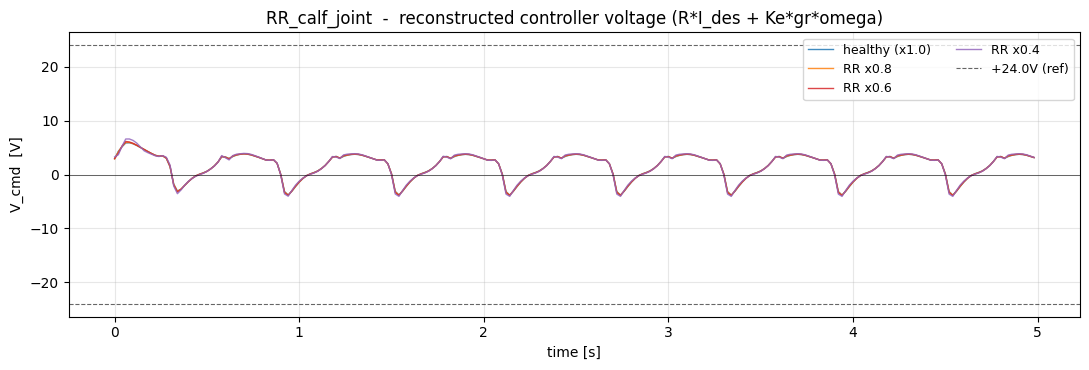

<Figure size 640x480 with 0 Axes>

In [87]:
R_PHASE    = 0.3     # [Ohm] Go2 모터 상저항 (go2_constants.py)
V_BUS_REF  = 24.0    # [V] 참고용 - 일반 Go2 배터리 버스 전압
JOINT      = "RR_calf_joint"

CASES_V = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]

fig, ax = plt.subplots(figsize=(11, 3.8))

print(f"{'case':<16} {'max |V|':>9} {'% of 24V':>10} "
      f"{'V_I term max':>13} {'V_ω term max':>13}")
print("-" * 68)

for label, path, color in CASES_V:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT)
    t = np.arange(m["num_steps"]) * m["dt"]

    I_des  = d["I_des"][:,  c]
    omega  = d["qd_all"][:, c]
    Kegr   = m["ke_nominal_joint"]

    V_I    = R_PHASE * I_des          # 저항 drop 성분
    V_emf  = Kegr    * omega          # back-EMF 성분
    V      = V_I + V_emf              # 총 컨트롤러 출력 전압

    ax.plot(t, V, color=color, lw=1.0, alpha=0.85, label=label)

    print(f"{label:<16} {np.max(np.abs(V)):>8.2f}V  "
          f"{100 * np.max(np.abs(V)) / V_BUS_REF:>8.1f}%  "
          f"{np.max(np.abs(V_I)):>11.2f}V  "
          f"{np.max(np.abs(V_emf)):>11.2f}V")

ax.axhline( V_BUS_REF, color="k", lw=0.8, ls="--", alpha=0.6, label=f"+{V_BUS_REF}V (ref)")
ax.axhline(-V_BUS_REF, color="k", lw=0.8, ls="--", alpha=0.6)
ax.axhline(0, color="k", lw=0.4)
ax.set_xlabel("time [s]")
ax.set_ylabel("V_cmd  [V]")
ax.set_title(f"{JOINT}  -  reconstructed controller voltage (R*I_des + Ke*gr*omega)")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

_apply_time_window()


## (b) τ_des vs τ_actual — demag 가 로봇에 주는 실제 영향

`tau_des` 는 컨트롤러가 **원하는** 관절 토크, `tau_actual` 은 **실제로 걸린** 관절 토크. V_bus 여유가 있어 `I_actual ≈ I_des` 이면 두 값의 차이는 순수하게 **plant Kt 감소 = Kt_nom×(1 − factor)** 때문에 생기고, 이게 로봇 움직임에 진짜 영향을 주는 성분입니다.

정상 주행 구간에서 한두 걸음만 떼서 보면 demag 기여가 깔끔하게 드러납니다. 걸음 경계는 `foot_contact` 의 FL 발 rising edge 두 개로 잡습니다.

In [88]:
JOINT      = "RR_calf_joint"
FOOT_NAME  = "RR_foot_collision"
WINDOW_SKIP_S = 5.0   # 처음 5 초는 transient 라 skip (걸음 탐색도 이후부터)

CASES_B = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
]


def find_two_strides(foot_flag, dt, t_skip):
    """RR 발의 rising edge 두 개를 찾아 (t0, t1) 구간 반환. 없으면 None.

    np.diff==1 은 '0→1' 전이 직전 인덱스를 주므로, 실제 첫 접촉 샘플은 +1.
    """
    k_skip = int(t_skip / dt)
    rising = np.where(np.diff(foot_flag[k_skip:].astype(int)) == 1)[0] + k_skip + 1
    if len(rising) < 3:
        return None
    # 두 걸음 = rising edge 3 개 사이 (0 → 1 → 2)
    k0, k1 = rising[0], rising[2]
    return k0, k1


# --- Pass 1: 창(window) 찾고, 공통 y/x 범위 계산 -----------------------------
prepared = []
y_min, y_max = np.inf, -np.inf
dur_max = 0.0
for label, path, color in CASES_B:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT)
    fc_col = m["foot_contact_names"].index(FOOT_NAME)
    t = np.arange(m["num_steps"]) * m["dt"]

    span = find_two_strides(d["foot_contact"][:, fc_col], m["dt"], WINDOW_SKIP_S)
    if span is None:
        print(f"[{label}] 두 걸음 구간을 못 찾음 — 전체 steady-state 구간 표시")
        k0 = int(WINDOW_SKIP_S / m["dt"]); k1 = k0 + int(1.5 / m["dt"])
    else:
        k0, k1 = span

    tau_d = d["tau_des"][k0:k1, c]
    tau_a = d["tau_actual"][k0:k1, c]
    y_min = min(y_min, tau_d.min(), tau_a.min())
    y_max = max(y_max, tau_d.max(), tau_a.max())
    dur_max = max(dur_max, (k1 - 1 - k0) * m["dt"])

    prepared.append((label, color, d, m, c, fc_col, t, k0, k1, tau_d, tau_a))

pad = 0.05 * (y_max - y_min)
y_lo, y_hi = y_min - pad, y_max + pad
x_lo, x_hi = 0.0, dur_max * 1.02

# --- Pass 2: 단일 torque 축 + 하단 contact 스트립 --------------------------
fig, (ax, ax_c) = plt.subplots(
    2, 1, figsize=(12, 5.0), sharex=True,
    gridspec_kw={"height_ratios": [5, 1], "hspace": 0.08},
)

stats_lines = []
for i, (label, color, d, m, c, fc_col, t, k0, k1, tau_d, tau_a) in enumerate(prepared):
    t_rel = t[k0:k1] - t[k0]

    # torque 곡선 — 케이스별 색, tau_des 는 점선(연하게) / tau_actual 은 실선
    ax.plot(t_rel, tau_d, color=color, ls="--", lw=1.2, alpha=0.55,
            label=f"{label}  tau_des")
    ax.plot(t_rel, tau_a, color=color, ls="-",  lw=1.8, alpha=0.95,
            label=f"{label}  tau_actual")

    # 하단 contact 스트립 — 케이스당 한 줄
    contact = d["foot_contact"][k0:k1, fc_col].astype(bool)
    ax_c.fill_between(t_rel, i + 0.05, i + 0.95,
                      where=contact, color=color, alpha=0.55, step="post")

    duty = float(contact.mean())
    gap  = tau_d - tau_a
    mae  = float(np.mean(np.abs(gap)))
    peak = float(np.max(np.abs(gap)))
    stats_lines.append(
        f"{label}: MAE={mae:.2f}, peak gap={peak:.2f}, stance duty={duty*100:.0f}%"
    )

# 상단 torque 축 꾸미기
ax.set_ylabel("torque [N*m]")
ax.set_title(f"{JOINT} — tau_des vs tau_actual (stride-aligned)\n"
             + "  |  ".join(stats_lines), fontsize=10)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.axhline(0, color="k", lw=0.4, alpha=0.4)

# 하단 contact 스트립 꾸미기
ax_c.set_yticks([i + 0.5 for i in range(len(prepared))])
ax_c.set_yticklabels([lbl for (lbl, *_) in prepared], fontsize=9)
ax_c.set_ylim(-0.1, len(prepared) + 0.1)
ax_c.invert_yaxis()   # healthy 를 위로 (prepared 순서대로 위→아래)
ax_c.set_xlabel("time since stride start [s]")
ax_c.set_ylabel("foot\ncontact", fontsize=9)
ax_c.grid(alpha=0.3, axis="x")

fig.tight_layout()
plt.show()

_apply_time_window()


[healthy (x1.0)] 두 걸음 구간을 못 찾음 — 전체 steady-state 구간 표시


ValueError: zero-size array to reduction operation minimum which has no identity

## (c) 속도 의존성 — `τ_actual/τ_des` ratio vs `|qd|`

plant 모델이 순수한 `τ = Kt_plant · I` 라면 ratio 는 속도 무관 상수 (= factor). 그런데 전류 필터 동역학 (`L·dI/dt`) 이 남아 있으면 **빠른 움직임 = 큰 |dI/dt| = 큰 R·I drop** 이 상대적으로 커져서 ratio 가 더 떨어집니다.

- ratio 가 모든 |qd| 에서 factor 근처 평평 → 저항 성분 무시 가능, 순수 Kt 감소로 설명 OK.\n
- |qd| 클수록 ratio 가 factor 아래로 처짐 → **L·dI/dt (혹은 R·ΔI) 가설** 의 직접 증거.

각 케이스별 산점도 + 이동평균선으로 확인합니다.

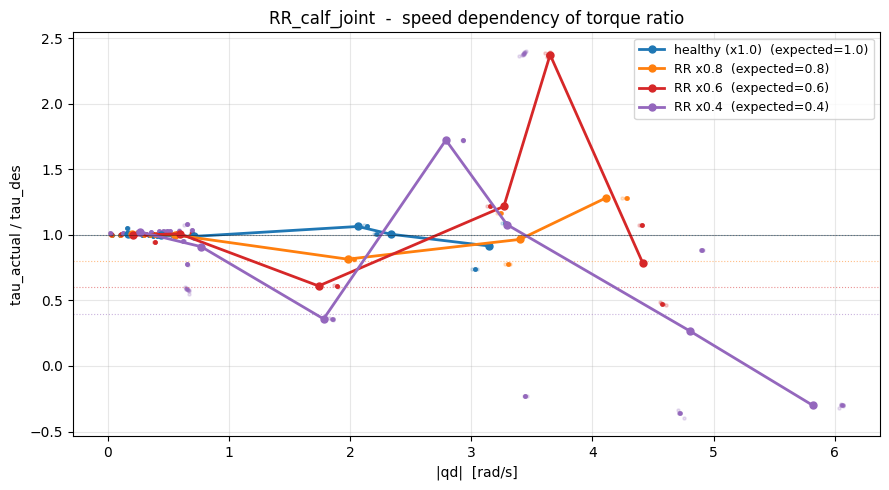


case             ratio | |qd|<2     ratio | |qd|>5     droop
--------------------------------------------------------------
healthy (x1.0)            1.0002               nan      +nan
RR x0.8                 1.0004               nan      +nan
RR x0.6                 0.9765               nan      +nan
RR x0.4                 0.9383           -0.3003   -1.2386


<Figure size 640x480 with 0 Axes>

In [ ]:
JOINT         = "RR_calf_joint"
TRANSIENT_S   = 1.0    # 1 초 이전은 과도기라 버림
TAU_MIN_NM    = 1.0    # |tau_des| < 이 값이면 ratio 가 0/0 로 발산하니 제외 [N*m]

CASES_C = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", 1.0, "tab:blue"),
    ("RR x0.8", "./data/aplus_tloop_ki200/RR_0.8.npz", 0.8, "tab:orange"),
    ("RR x0.6", "./data/aplus_tloop_ki200/RR_0.6.npz", 0.6, "tab:red"),
    ("RR x0.4", "./data/aplus_tloop_ki200/RR_0.4.npz", 0.4, "tab:purple"),
]

# |qd| 를 bin 으로 나눠 bin 평균 ratio 를 그려 속도 트렌드 확인
NUM_BINS = 12


def binned_mean(x, y, n_bins):
    """x 를 균등 bin 으로 나눠 각 bin 의 (x_center, y_mean) 반환."""
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers, means = [], []
    for i in range(n_bins):
        sel = (x >= edges[i]) & (x < edges[i + 1])
        if sel.sum() >= 5:   # 데이터 점이 5 개 이상일 때만 사용
            centers.append(0.5 * (edges[i] + edges[i + 1]))
            means.append(float(np.mean(y[sel])))
    return np.array(centers), np.array(means)


fig, ax = plt.subplots(figsize=(9, 5))

for label, path, factor, color in CASES_C:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT)
    k0 = int(TRANSIENT_S / m["dt"])

    tau_des    = d["tau_des"][k0:,    c]
    tau_actual = d["tau_actual"][k0:, c]
    qd         = d["qd_all"][k0:,     c]

    # 0/0 방지: |tau_des| 가 너무 작은 step 제외
    ok     = np.abs(tau_des) > TAU_MIN_NM
    ratio  = tau_actual[ok] / tau_des[ok]
    absqd  = np.abs(qd[ok])

    # 산점도
    ax.scatter(absqd, ratio, s=5, color=color, alpha=0.2)
    # bin 평균선
    xc, ym = binned_mean(absqd, ratio, NUM_BINS)
    ax.plot(xc, ym, color=color, lw=2.0, marker="o", ms=5,
            label=f"{label}  (expected={factor})")
    # 기대치 수평 점선
    ax.axhline(factor, color=color, lw=0.8, ls=":", alpha=0.5)

ax.axhline(1.0, color="k", lw=0.6, alpha=0.4)
ax.set_xlabel("|qd|  [rad/s]")
ax.set_ylabel("tau_actual / tau_des")
ax.set_title(f"{JOINT}  -  speed dependency of torque ratio")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

# bin 평균 ratio 를 |qd| 저속/고속 두 구간으로 나눠 요약
print(f"\n{'case':<12} {'ratio | |qd|<2':>18} {'ratio | |qd|>5':>18} {'droop':>9}")
print("-" * 62)
for label, path, factor, _ in CASES_C:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    c = m["q_all_joint_names"].index(JOINT)
    k0 = int(TRANSIENT_S / m["dt"])
    tau_des    = d["tau_des"][k0:,    c]
    tau_actual = d["tau_actual"][k0:, c]
    qd         = d["qd_all"][k0:,     c]
    ok = np.abs(tau_des) > TAU_MIN_NM
    ratio = tau_actual[ok] / tau_des[ok]
    absqd = np.abs(qd[ok])
    lo = ratio[absqd < 2.0]
    hi = ratio[absqd > 5.0]
    r_lo = float(np.mean(lo)) if len(lo) else float("nan")
    r_hi = float(np.mean(hi)) if len(hi) else float("nan")
    print(f"{label:<12} {r_lo:>17.4f} {r_hi:>17.4f} {r_hi - r_lo:>+9.4f}")

_apply_time_window()


## (1) cmd_vel vs base_lin_vel — 명령 속도 추종

`cmd_vel` 은 실험 내내 `(vx=0.5, vy=0, wz=0)` 으로 고정. `base_lin_vel` (body frame) 이 얼마나 이를 추종하는지가 고장이 locomotion 으로 전파되는지의 1차 지표입니다.

- `vx` 가 0.5 근처에 머무는지 (앞으로 가는 속도).
- `vy`, 각속도 `wz` 가 0 근처에서 벗어나면 측방 drift / yaw 회전으로 기울어진다는 뜻.

한 다리만 약해졌을 때 RL policy 가 **다른 다리 보상으로 평균 속도를 유지** 하는지, 아니면 **누적된 드리프트/회전** 으로 코스를 이탈하는지가 포인트.

case               mean vx   std vx   mean vy   std vy   mean wz   std wz
------------------------------------------------------------------------
healthy (x1.0)      0.444    0.029     0.042    0.032    -0.023    0.026
RR x0.8             0.444    0.029     0.042    0.032    -0.023    0.027
RR x0.6             0.445    0.030     0.041    0.033    -0.023    0.028
RR x0.4             0.445    0.032     0.041    0.034    -0.024    0.030


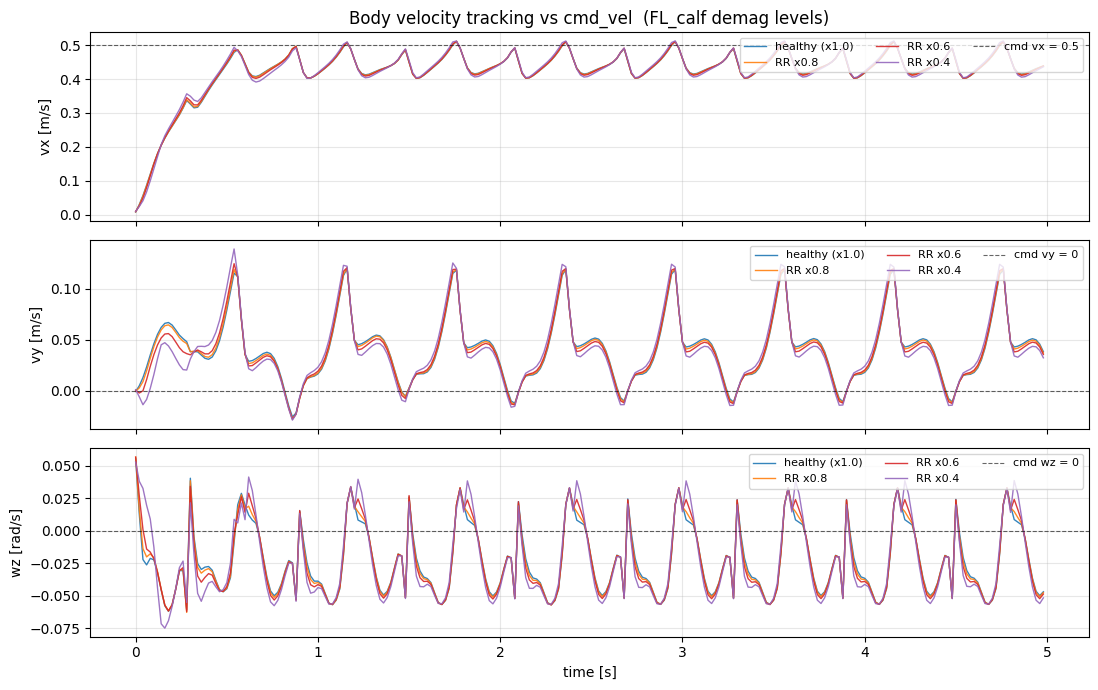

<Figure size 640x480 with 0 Axes>

In [99]:
TRANSIENT_S = 1.0   # 초기 transient 는 통계에서 제외

CASES_LOC = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

print(f"{'case':<16} {'mean vx':>9} {'std vx':>8} {'mean vy':>9} "
      f"{'std vy':>8} {'mean wz':>9} {'std wz':>8}")
print("-" * 72)

for label, path, color in CASES_LOC:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    t = np.arange(m["num_steps"]) * m["dt"]

    vx = d["base_lin_vel"][:, 0]   # forward
    vy = d["base_lin_vel"][:, 1]   # lateral
    wz = d["base_ang_vel"][:, 2]   # yaw rate

    axes[0].plot(t, vx, color=color, lw=1.0, alpha=0.9, label=label)
    axes[1].plot(t, vy, color=color, lw=1.0, alpha=0.9, label=label)
    axes[2].plot(t, wz, color=color, lw=1.0, alpha=0.9, label=label)

    # 통계 (정상상태)
    k0 = int(TRANSIENT_S / m["dt"])
    print(f"{label:<16} {np.mean(vx[k0:]):>8.3f}  {np.std(vx[k0:]):>7.3f}  "
          f"{np.mean(vy[k0:]):>8.3f}  {np.std(vy[k0:]):>7.3f}  "
          f"{np.mean(wz[k0:]):>8.3f}  {np.std(wz[k0:]):>7.3f}")

# cmd line (vx=0.5 일정, vy·wz 는 0)
axes[0].axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.6, label="cmd vx = 0.5")
axes[1].axhline(0.0, color="k", lw=0.8, ls="--", alpha=0.6, label="cmd vy = 0")
axes[2].axhline(0.0, color="k", lw=0.8, ls="--", alpha=0.6, label="cmd wz = 0")

axes[0].set_ylabel("vx [m/s]")
axes[1].set_ylabel("vy [m/s]")
axes[2].set_ylabel("wz [rad/s]")
axes[2].set_xlabel("time [s]")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=3)
axes[0].set_title("Body velocity tracking vs cmd_vel  (FL_calf demag levels)")
fig.tight_layout()
plt.show()

_apply_time_window()


## (2) q_des vs q_all — joint-level 추종 RMS error

`q_des` 는 정책이 내린 관절 위치 목표, `q_all` 은 실제 관절 각. 고장 다리는 토크가 모자라 **자기 자신 joint 추종이 먼저 깨지는지**, 아니면 **다른 다리로 보상이 가면서 오히려 다른 관절 추종이 나빠지는지** 를 보여줍니다.

세 구분:
1. **12 joint RMSE 바 차트** (healthy vs 특정 demag 레벨) — 어느 joint 가 가장 많이 흔들리는지 한눈에.
2. **faulted joint (FL_calf) 시계열** — q_des vs q_all 겹침.
3. **대각 반대편 (RR_calf) 시계열** — 고장 다리 보상으로 상대 쪽이 흔들리는지 (FL 고장 → RR 에 부담 전이 여부).

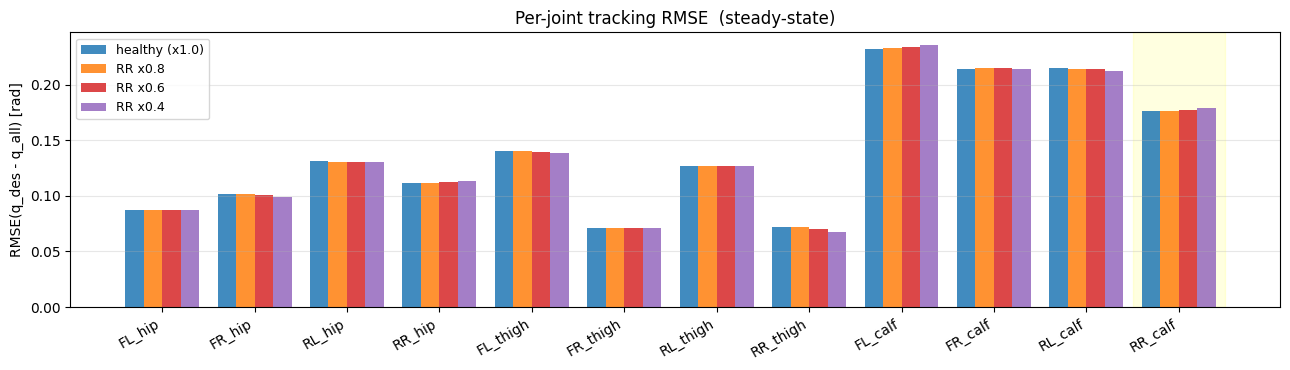

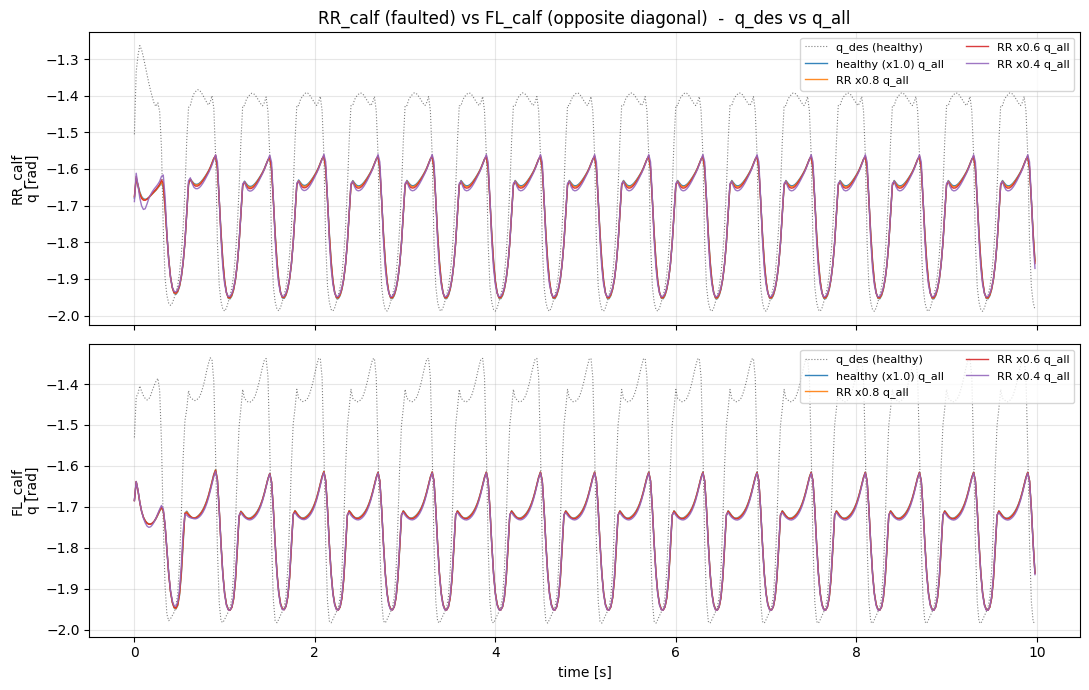


[per-joint RMSE, rad] (faulted joint = RR_calf, highlighted yellow above)
case                  FL_hip      FR_hip      RL_hip      RR_hip    FL_thigh    FR_thigh    RL_thigh    RR_thigh     FL_calf     FR_calf     RL_calf     RR_calf
----------------------------------------------------------------------------------------------------------------------------------------------------------------
healthy (x1.0)        0.0870      0.1017      0.1309      0.1114      0.1405      0.0714      0.1271      0.0722      0.2324      0.2144      0.2147      0.1762
RR x0.8               0.0870      0.1013      0.1308      0.1117      0.1400      0.0714      0.1268      0.0716      0.2329      0.2145      0.2143      0.1767
RR x0.6               0.0872      0.1007      0.1308      0.1122      0.1393      0.0712      0.1265      0.0704      0.2335      0.2145      0.2137      0.1775
RR x0.4               0.0870      0.0993      0.1306      0.1131      0.1382      0.0712      0.1266      0.0673      0.

<Figure size 640x480 with 0 Axes>

In [ ]:
TRANSIENT_S = 1.0

CASES_JT = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]


def rmse_per_joint(d, meta, t_skip):
    """각 joint 에 대해 steady-state 구간의 RMSE(q_des - q_all) 반환 (shape (12,))."""
    k0 = int(t_skip / meta["dt"])
    err = d["q_des"][k0:, :] - d["q_all"][k0:, :]
    return np.sqrt(np.mean(err ** 2, axis=0))


# ── 1. 12 joint RMSE 바 차트 (케이스별 나란히) ──────────────────
# 샘플 meta 하나 로드해서 joint 이름 얻기
joint_names = json.loads(str(np.load(CASES_JT[0][1], allow_pickle=True)["meta"]))["q_all_joint_names"]
# 보기 좋게 짧은 이름으로 (..._joint 떼기)
short_names = [n.replace("_joint", "") for n in joint_names]

rmse_table = []
for label, path, _ in CASES_JT:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    rmse_table.append(rmse_per_joint(d, m, TRANSIENT_S))
rmse_table = np.array(rmse_table)   # shape (num_cases, 12)

fig, ax = plt.subplots(figsize=(13, 3.8))
x = np.arange(12)
w = 0.20
for i, (label, _, color) in enumerate(CASES_JT):
    ax.bar(x + (i - 1.5) * w, rmse_table[i], w, color=color, alpha=0.85, label=label)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_ylabel("RMSE(q_des - q_all) [rad]")
ax.set_title("Per-joint tracking RMSE  (steady-state)")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=9)
# 고장 joint 강조 (RR_calf)
fault_col = joint_names.index("RR_calf_joint")
ax.axvspan(fault_col - 0.5, fault_col + 0.5, color="yellow", alpha=0.12, zorder=0)
fig.tight_layout()
plt.show()

# ── 2,3. 특정 joint 시계열 (FL_calf = faulted leg, RR_calf = 반대편) ──
FOCUS_JOINTS = ["RR_calf_joint", "FL_calf_joint"]

fig, axes = plt.subplots(len(FOCUS_JOINTS), 1, figsize=(11, 3.5 * len(FOCUS_JOINTS)), sharex=True)

for ax, joint_name in zip(axes, FOCUS_JOINTS):
    c = joint_names.index(joint_name)
    for label, path, color in CASES_JT:
        d = np.load(path, allow_pickle=True)
        m = json.loads(str(d["meta"]))
        t = np.arange(m["num_steps"]) * m["dt"]
        # q_des 를 회색 계열 한 번만 (모든 케이스 거의 유사하므로 혼잡 방지)
        if label == CASES_JT[0][0]:
            ax.plot(t, d["q_des"][:, c], color="black", lw=0.8, ls=":", alpha=0.5, label="q_des (healthy)")
        ax.plot(t, d["q_all"][:, c], color=color, lw=1.0, alpha=0.9, label=f"{label} q_all")
    ax.set_ylabel(f"{joint_name.replace('_joint', '')}\nq [rad]")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
axes[-1].set_xlabel("time [s]")
axes[0].set_title("RR_calf (faulted) vs FL_calf (opposite diagonal)  -  q_des vs q_all")
fig.tight_layout()
plt.show()

# 요약 출력
print(f"\n[per-joint RMSE, rad] (faulted joint = RR_calf, highlighted yellow above)")
hdr = f"{'case':<16}  " + "  ".join(f"{n:>10}" for n in short_names)
print(hdr)
print("-" * len(hdr))
for (label, _, _), rmse in zip(CASES_JT, rmse_table):
    row = f"{label:<16}  " + "  ".join(f"{v:>10.4f}" for v in rmse)
    print(row)

_apply_time_window()


## (3) base_rpy · base_pos_z — 자세 흔들림과 고도 드리프트

한 다리만 약해졌을 때 밸런싱이 어떻게 가는지:

- **roll** (좌우 기울임): 좌측 FL 약화 → 몸통이 왼쪽으로 기우는지.
- **pitch** (앞뒤 기울임): 앞다리 (FL / FR) 약화 → 코가 숙여지는지 / 들리는지.
- **yaw drift**: wz 가 장기적으로 bias 되면 직선에서 벗어남.
- **base z (world)**: 높이 유지 실패 → 지면 충돌 직전.
- **xy trajectory**: 측방 drift 누적 — 직선 코스에서 얼마나 벗어나는가.

Healthy 는 기준선 역할, fault 레벨은 단계적으로 (0.8 → 0.4) 비교.

case              |roll|max  |pitch|max  |yaw drift|   z mean   z std
------------------------------------------------------------------------
healthy (x1.0)        1.90 deg     1.11 deg      -6.61 deg   0.309m  0.001m
RR x0.8               1.92 deg     1.09 deg      -6.63 deg   0.309m  0.001m
RR x0.6               1.94 deg     1.09 deg      -6.66 deg   0.309m  0.001m
RR x0.4               2.01 deg     1.15 deg      -6.82 deg   0.309m  0.001m


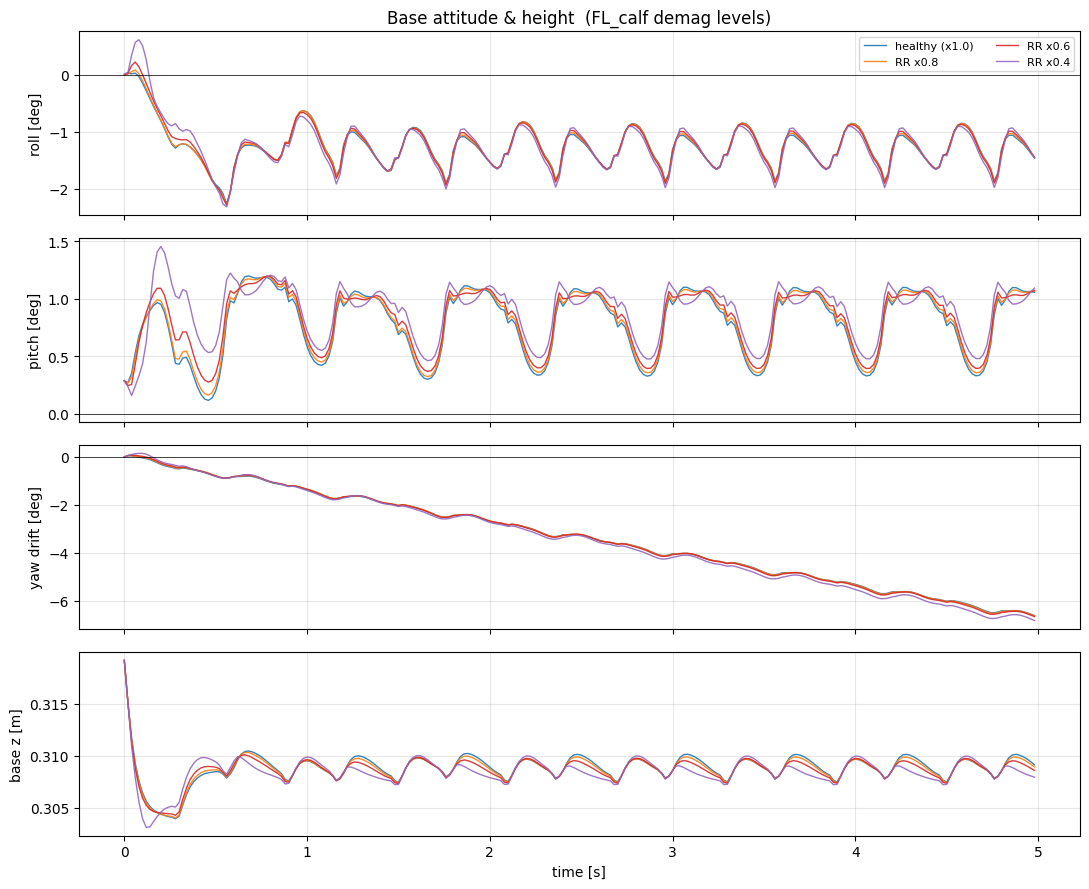

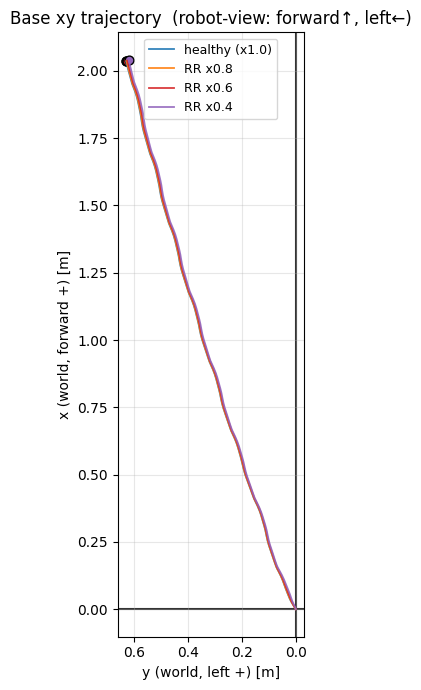

<Figure size 640x480 with 0 Axes>

In [ ]:
TRANSIENT_S = 1.0

CASES_POSE = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]

# ── 4개 시계열 subplot: roll, pitch, yaw, z ──
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

print(f"{'case':<16} {'|roll|max':>10} {'|pitch|max':>11} {'|yaw drift|':>12} "
      f"{'z mean':>8} {'z std':>7}")
print("-" * 72)

for label, path, color in CASES_POSE:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    t = np.arange(m["num_steps"]) * m["dt"]

    rpy_deg = np.rad2deg(d["base_rpy"])
    roll, pitch, yaw = rpy_deg[:, 0], rpy_deg[:, 1], rpy_deg[:, 2]
    z = d["base_pos"][:, 2]

    axes[0].plot(t, roll,  color=color, lw=1.0, alpha=0.9, label=label)
    axes[1].plot(t, pitch, color=color, lw=1.0, alpha=0.9, label=label)
    # yaw 는 0 에서 시작하도록 offset (자세 drift 만 보려고)
    axes[2].plot(t, yaw - yaw[0], color=color, lw=1.0, alpha=0.9, label=label)
    axes[3].plot(t, z,     color=color, lw=1.0, alpha=0.9, label=label)

    # 통계
    k0 = int(TRANSIENT_S / m["dt"])
    print(f"{label:<16} {np.max(np.abs(roll[k0:])):>9.2f} deg  "
          f"{np.max(np.abs(pitch[k0:])):>7.2f} deg  "
          f"{(yaw[-1] - yaw[0]):>9.2f} deg  "
          f"{np.mean(z[k0:]):>6.3f}m  {np.std(z[k0:]):>5.3f}m")

axes[0].axhline(0, color="k", lw=0.5)
axes[1].axhline(0, color="k", lw=0.5)
axes[2].axhline(0, color="k", lw=0.5)

axes[0].set_ylabel("roll [deg]")
axes[1].set_ylabel("pitch [deg]")
axes[2].set_ylabel("yaw drift [deg]")
axes[3].set_ylabel("base z [m]")
axes[3].set_xlabel("time [s]")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8, ncol=2)
axes[0].set_title("Base attitude & height  (RR_calf demag levels)")
fig.tight_layout()
plt.show()

# ── xy trajectory (world frame, robot-view orientation) ──
fig, ax = plt.subplots(figsize=(5, 7))   # 세로로 긴 figure가 더 자연스러움
for label, path, color in CASES_POSE:
    d = np.load(path, allow_pickle=True)
    x = d["base_pos"][:, 0] - d["base_pos"][0, 0]   # forward (world +x)
    y = d["base_pos"][:, 1] - d["base_pos"][0, 1]   # left    (world +y)
    # 가로축 = y (왼쪽이 +y), 세로축 = x (위쪽이 +x)
    ax.plot(y, x, color=color, lw=1.3, alpha=0.9, label=label)
    ax.scatter(y[-1], x[-1], color=color, s=40, marker="o", edgecolor="k")

# 원점을 지나는 기준선 강조
ax.axhline(0, color="k", lw=1.5, alpha=0.8, zorder=0)   # world x = 0
ax.axvline(0, color="k", lw=1.5, alpha=0.8, zorder=0)   # world y = 0
ax.set_xlabel("y (world, left +) [m]")
ax.set_ylabel("x (world, forward +) [m]")
ax.invert_xaxis()                 # +y(왼쪽)이 화면 왼쪽으로 가도록 반전
ax.set_aspect("equal")
ax.set_title("Base xy trajectory  (robot-view: forward↑, left←)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

_apply_time_window()


## (4) 다른 관절 거동 — 고장 다리 부하 재분배

RR_calf 하나만 약해졌을 때 다른 세 다리가 그 부하를 나눠 지는지를 봅니다.

- **대각선 다리 (FL)**: 4 족 보행에서 RR 와 pair 로 같이 움직이는 다리. 여기 current 가 눈에 띄게 올라가면 정책이 의도적으로 대각을 "더 밀어" 복원한다는 증거.
- **동측 다리 (RL)**: 같은 뒷다리. 같은 stride phase 에 땅에 닿으므로 자연스레 분담 가능성 있음.
- **대측 앞다리 (FR)**: RR 와 phase 가 반대라 보상 효과는 약할 것으로 예상.

세 지표를 같이 봅니다:
1. **관절별 평균 |I_actual|** (12 관절 × 여러 case 바 차트) — 어느 관절로 부하가 가는지.
2. **다리별 총 |I_actual|** (hip+thigh+calf 합) — 다리 단위로 보상 흐름.
3. **전체 전력** (copper loss `R·Σ I²`) — 총 에너지 소비가 올랐는지.

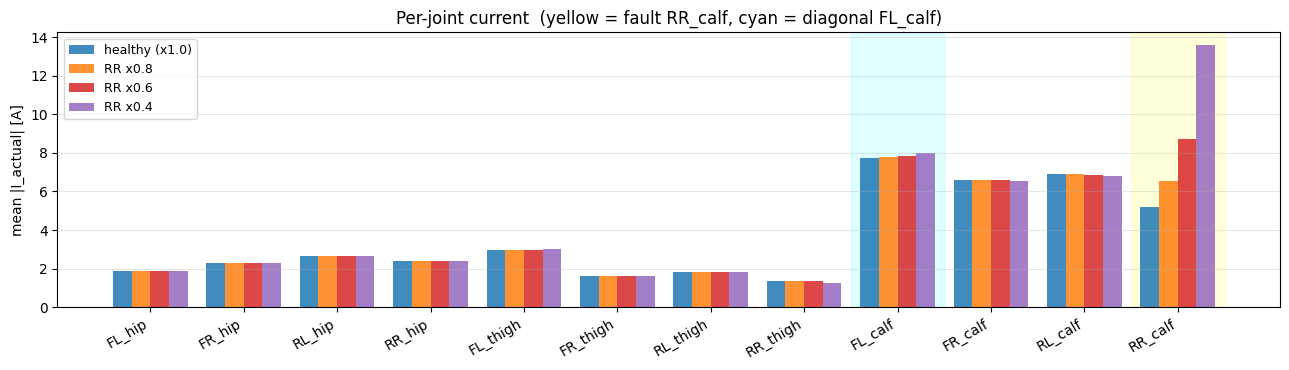

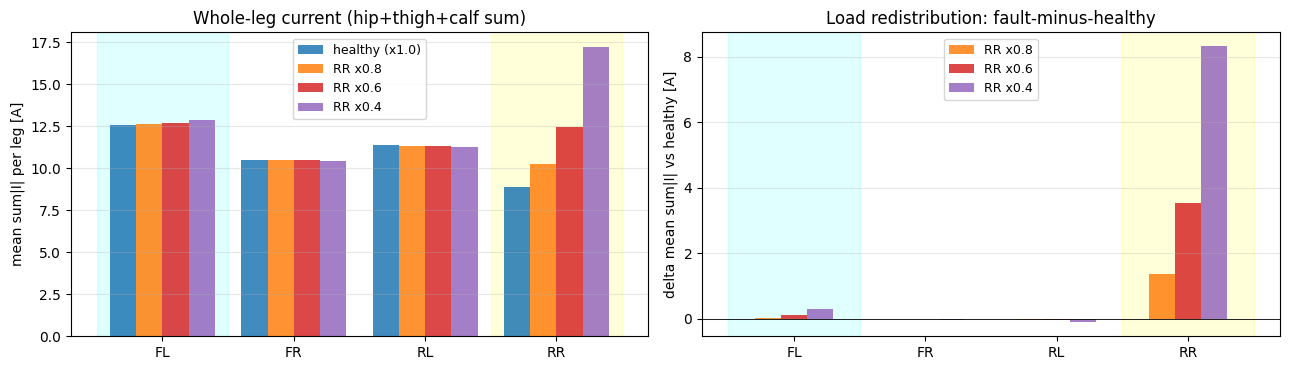

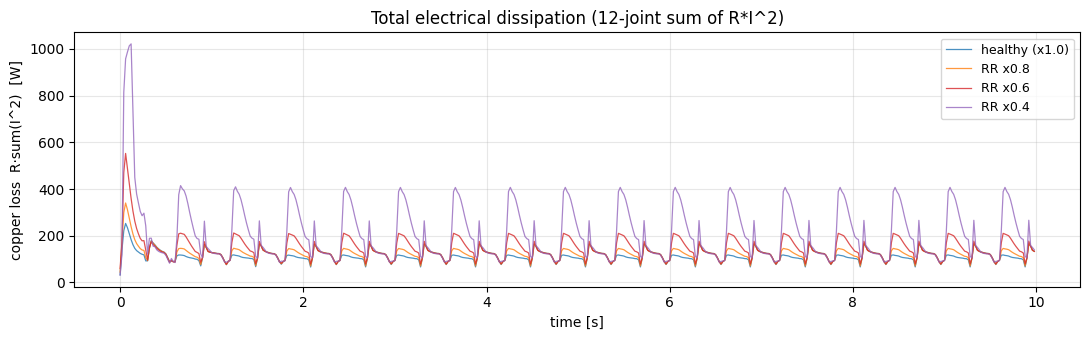


case                FL sum|I|    FR sum|I|    RL sum|I|    RR sum|I|   copper [W]
---------------------------------------------------------------------------------
healthy (x1.0)         12.599       10.495       11.380        8.914      112.706
RR x0.8                12.633       10.490       11.354       10.275      121.196
RR x0.6                12.700       10.481       11.324       12.459      140.169
RR x0.4                12.900       10.451       11.264       17.239      197.616

Delta vs healthy (positive = more load on that leg):
case                FL sum|I|    FR sum|I|    RL sum|I|    RR sum|I|   copper [W]
---------------------------------------------------------------------------------
RR x0.8                +0.034       -0.005       -0.026       +1.361       +8.490
RR x0.6                +0.101       -0.014       -0.056       +3.545      +27.463
RR x0.4                +0.301       -0.044       -0.116       +8.325      +84.910


<Figure size 640x480 with 0 Axes>

In [ ]:
TRANSIENT_S = 1.0
R_PHASE     = 0.3   # 모터 상저항 [Ohm]

CASES_RD = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]

LEGS           = ["FL", "FR", "RL", "RR"]
JOINTS_PER_LEG = ["hip", "thigh", "calf"]

# 샘플 meta 에서 joint 이름 & 열 맵 구축
sample_meta = json.loads(str(np.load(CASES_RD[0][1], allow_pickle=True)["meta"]))
jnames      = sample_meta["q_all_joint_names"]
short_names = [n.replace("_joint", "") for n in jnames]
calf_col    = {leg: jnames.index(f"{leg}_calf_joint") for leg in LEGS}
leg_cols    = {leg: [jnames.index(f"{leg}_{j}_joint") for j in JOINTS_PER_LEG]
               for leg in LEGS}

FAULT_LEG = "RR"   # 이번 실험의 고장 다리
DIAG_LEG  = "FL"   # 대각 pair

# 케이스별로 집계
joint_means  = []   # (n_cases, 12)  평균 |I_actual|
leg_means    = {leg: [] for leg in LEGS}   # 다리별 총 |I| 평균
copper_mean  = []   # 총 copper loss 평균 [W]
copper_trace = []   # 시계열 (플롯용)
times        = []

for label, path, color in CASES_RD:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    k0 = int(TRANSIENT_S / m["dt"])
    t  = np.arange(m["num_steps"]) * m["dt"]

    I      = d["I_actual"][k0:, :]    # shape (N, 12)
    absI   = np.abs(I)
    joint_means.append(absI.mean(axis=0))                           # (12,)
    for leg in LEGS:
        leg_means[leg].append(float(absI[:, leg_cols[leg]].sum(axis=1).mean()))
    copper_t = R_PHASE * (I ** 2).sum(axis=1)                        # [W] 시계열 (k0~)
    copper_mean.append(float(copper_t.mean()))
    copper_trace.append(R_PHASE * (d["I_actual"] ** 2).sum(axis=1))  # 전체 구간
    times.append(t)

joint_means = np.array(joint_means)   # (n_cases, 12)

# ── Figure 1: 관절별 평균 |I_actual| 바 차트 (12 joints × cases) ──
fig, ax = plt.subplots(figsize=(13, 3.8))
x = np.arange(12)
w = 0.20
for i, (label, _, color) in enumerate(CASES_RD):
    ax.bar(x + (i - 1.5) * w, joint_means[i], w, color=color, alpha=0.85, label=label)
# 고장 calf 와 대각 calf 강조
ax.axvspan(jnames.index(f"{FAULT_LEG}_calf_joint") - 0.5,
           jnames.index(f"{FAULT_LEG}_calf_joint") + 0.5,
           color="yellow", alpha=0.15, zorder=0)
ax.axvspan(jnames.index(f"{DIAG_LEG}_calf_joint") - 0.5,
           jnames.index(f"{DIAG_LEG}_calf_joint") + 0.5,
           color="cyan", alpha=0.12, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha="right")
ax.set_ylabel("mean |I_actual| [A]")
ax.set_title(f"Per-joint current  (yellow = fault {FAULT_LEG}_calf, cyan = diagonal {DIAG_LEG}_calf)")
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ── Figure 2: 다리별 총 |I_actual| 바 차트 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

x = np.arange(4)
for i, (label, _, color) in enumerate(CASES_RD):
    vals = [leg_means[leg][i] for leg in LEGS]
    axes[0].bar(x + (i - 1.5) * w, vals, w, color=color, alpha=0.85, label=label)
axes[0].axvspan(LEGS.index(FAULT_LEG) - 0.5, LEGS.index(FAULT_LEG) + 0.5,
                color="yellow", alpha=0.15, zorder=0)
axes[0].axvspan(LEGS.index(DIAG_LEG) - 0.5, LEGS.index(DIAG_LEG) + 0.5,
                color="cyan", alpha=0.12, zorder=0)
axes[0].set_xticks(x); axes[0].set_xticklabels(LEGS)
axes[0].set_ylabel("mean sum|I| per leg [A]")
axes[0].set_title("Whole-leg current (hip+thigh+calf sum)")
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend(fontsize=9)

# ── healthy 대비 Δ(leg current) 바 차트 — 재분배가 시각적으로 뚜렷 ──
base = np.array([leg_means[leg][0] for leg in LEGS])   # healthy 값
for i, (label, _, color) in enumerate(CASES_RD):
    if i == 0:
        continue   # healthy 자기 자신은 0
    delta = np.array([leg_means[leg][i] for leg in LEGS]) - base
    axes[1].bar(x + (i - 2) * w, delta, w, color=color, alpha=0.85, label=label)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].axvspan(LEGS.index(FAULT_LEG) - 0.5, LEGS.index(FAULT_LEG) + 0.5,
                color="yellow", alpha=0.15, zorder=0)
axes[1].axvspan(LEGS.index(DIAG_LEG) - 0.5, LEGS.index(DIAG_LEG) + 0.5,
                color="cyan", alpha=0.12, zorder=0)
axes[1].set_xticks(x); axes[1].set_xticklabels(LEGS)
axes[1].set_ylabel("delta mean sum|I| vs healthy [A]")
axes[1].set_title("Load redistribution: fault-minus-healthy")
axes[1].grid(alpha=0.3, axis="y")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

# ── Figure 3: 총 copper loss 시계열 + 평균 ──
fig, ax = plt.subplots(figsize=(11, 3.5))
for (label, _, color), t, trace in zip(CASES_RD, times, copper_trace):
    ax.plot(t, trace, color=color, lw=0.9, alpha=0.8, label=label)
ax.set_xlabel("time [s]")
ax.set_ylabel("copper loss  R·sum(I^2)  [W]")
ax.set_title("Total electrical dissipation (12-joint sum of R*I^2)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ── 요약 표 ──
header = f"{'case':<16}" + "".join(f"{leg+' sum|I|':>13}" for leg in LEGS) + f"{'copper [W]':>13}"
print(f"\n{header}")
print("-" * len(header))
for i, (label, _, _) in enumerate(CASES_RD):
    row = f"{label:<16}" + "".join(f"{leg_means[leg][i]:>13.3f}" for leg in LEGS)           + f"{copper_mean[i]:>13.3f}"
    print(row)

print(f"\nDelta vs healthy (positive = more load on that leg):")
print(header)
print("-" * len(header))
for i, (label, _, _) in enumerate(CASES_RD):
    if i == 0:
        continue
    row = f"{label:<16}"
    for leg in LEGS:
        row += f"{leg_means[leg][i] - leg_means[leg][0]:>+13.3f}"
    row += f"{copper_mean[i] - copper_mean[0]:>+13.3f}"
    print(row)

_apply_time_window()


## (5a) Per-leg Work — 기계적 기여도

전류 합만 보면 "어느 다리가 더 힘쓰는지" 가 그럴싸하게 보이지만, 실제 **로봇을 움직이는 에너지** 는 `P = τ · qd` (기계 파워) 입니다. 전류가 커져도 움직이지 않으면 (qd ≈ 0) 기계적으로는 0 W 일 뿐 copper loss 만 내고 있을 수도 있음.

각 다리의 `hip + thigh + calf` 에 대해 `P_leg = Σ τ_actual · qd` 시계열을 만들어 두 가지로 씁니다:

- **mean P_leg** (signed) — **순 에너지 흐름**: 양수는 다리가 body 에 에너지 주입 (push), 음수는 다리가 body 에너지 흡수 (damping).
- **mean |P_leg|** — **근육 노력**: 부호 상관없이 얼마나 활발히 일하는지.

두 지표를 (4) 의 전류 지표와 나란히 봐서 "전류는 늘었는데 기계 work 는 줄었다" 같은 비효율 구간을 포착할 수 있습니다.

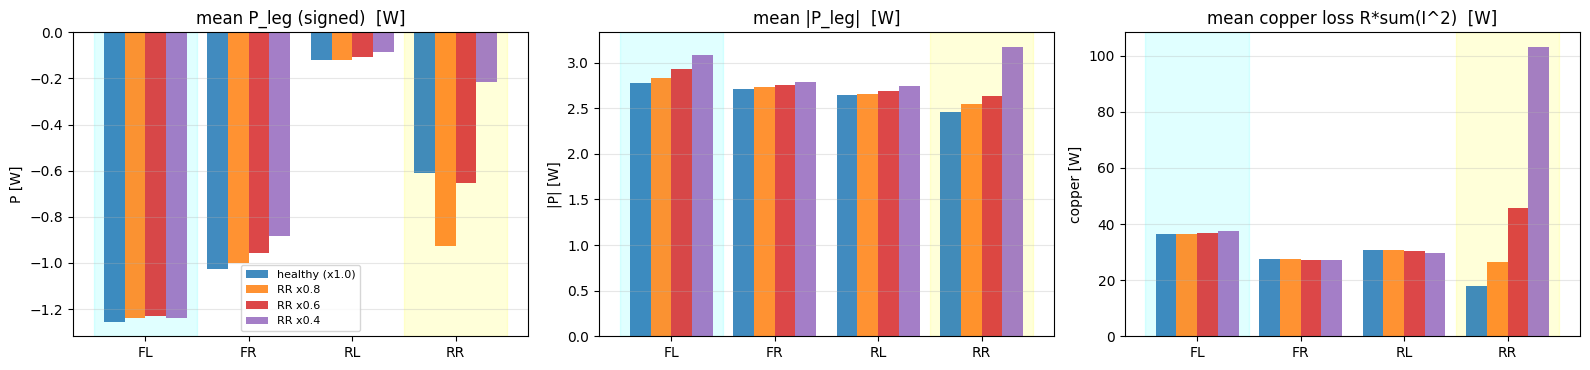

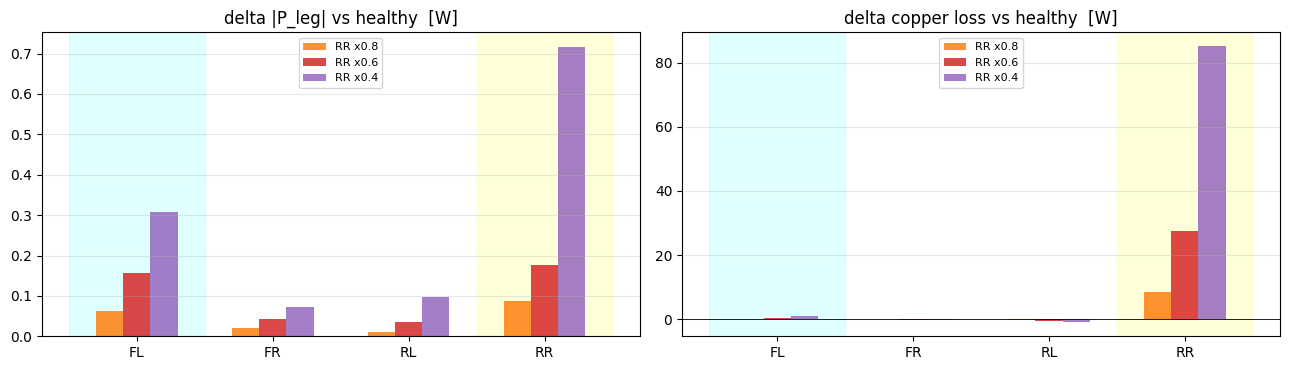

case                FL |P| [W]    FR |P| [W]    RL |P| [W]    RR |P| [W]   total |P|
------------------------------------------------------------------------------------
healthy (x1.0)           2.772         2.712         2.649         2.456      10.588
RR x0.8                  2.834         2.733         2.660         2.542      10.770
RR x0.6                  2.928         2.755         2.686         2.632      11.001
RR x0.4                  3.079         2.784         2.747         3.172      11.782

Delta vs healthy  |P_leg|  [W]   (positive = leg does more mechanical work)
case                FL |P| [W]    FR |P| [W]    RL |P| [W]    RR |P| [W]   total |P|
------------------------------------------------------------------------------------
RR x0.8                 +0.063        +0.021        +0.011        +0.086      +0.181
RR x0.6                 +0.156        +0.044        +0.036        +0.177      +0.413
RR x0.4                 +0.307        +0.072        +0.097        +0.717 

<Figure size 640x480 with 0 Axes>

In [ ]:
TRANSIENT_S = 1.0
R_PHASE     = 0.3

CASES_WK = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]
LEGS           = ["FL", "FR", "RL", "RR"]
JOINTS_PER_LEG = ["hip", "thigh", "calf"]
FAULT_LEG = "RR"
DIAG_LEG  = "FL"

sample_meta = json.loads(str(np.load(CASES_WK[0][1], allow_pickle=True)["meta"]))
jnames = sample_meta["q_all_joint_names"]
leg_cols = {leg: [jnames.index(f"{leg}_{j}_joint") for j in JOINTS_PER_LEG] for leg in LEGS}

# 각 케이스 · 각 다리의 평균 mechanical power (signed, |·|), copper loss
P_signed = {leg: [] for leg in LEGS}
P_abs    = {leg: [] for leg in LEGS}
CU       = {leg: [] for leg in LEGS}

for label, path, _ in CASES_WK:
    d  = np.load(path, allow_pickle=True)
    m  = json.loads(str(d["meta"]))
    k0 = int(TRANSIENT_S / m["dt"])
    tau = d["tau_actual"][k0:, :]
    qd  = d["qd_all"][k0:, :]
    I   = d["I_actual"][k0:, :]

    for leg in LEGS:
        cols = leg_cols[leg]
        # leg 당 총 기계 파워 시계열 = sum over joints of tau*qd
        P_leg_t = (tau[:, cols] * qd[:, cols]).sum(axis=1)
        P_signed[leg].append(float(P_leg_t.mean()))
        P_abs[leg].append(float(np.abs(P_leg_t).mean()))
        # copper loss per leg
        cu_leg_t = R_PHASE * (I[:, cols] ** 2).sum(axis=1)
        CU[leg].append(float(cu_leg_t.mean()))

# ── Figure: 3 x 1 bar charts (signed P, |P|, copper) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
x = np.arange(4)
w = 0.20

for i, (label, _, color) in enumerate(CASES_WK):
    axes[0].bar(x + (i - 1.5) * w, [P_signed[leg][i] for leg in LEGS], w, color=color, alpha=0.85, label=label)
    axes[1].bar(x + (i - 1.5) * w, [P_abs[leg][i]    for leg in LEGS], w, color=color, alpha=0.85, label=label)
    axes[2].bar(x + (i - 1.5) * w, [CU[leg][i]       for leg in LEGS], w, color=color, alpha=0.85, label=label)

for ax, title, ylab in zip(axes,
                            ["mean P_leg (signed)  [W]",
                             "mean |P_leg|  [W]",
                             "mean copper loss R*sum(I^2)  [W]"],
                            ["P [W]", "|P| [W]", "copper [W]"]):
    ax.axhline(0, color="k", lw=0.6)
    ax.axvspan(LEGS.index(FAULT_LEG) - 0.5, LEGS.index(FAULT_LEG) + 0.5, color="yellow", alpha=0.15, zorder=0)
    ax.axvspan(LEGS.index(DIAG_LEG)  - 0.5, LEGS.index(DIAG_LEG)  + 0.5, color="cyan",   alpha=0.12, zorder=0)
    ax.set_xticks(x); ax.set_xticklabels(LEGS)
    ax.set_title(title); ax.set_ylabel(ylab)
    ax.grid(alpha=0.3, axis="y")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

# ── Delta vs healthy (재분배 방향 뚜렷) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for i, (label, _, color) in enumerate(CASES_WK):
    if i == 0: continue
    d_P  = [P_abs[leg][i] - P_abs[leg][0] for leg in LEGS]
    d_CU = [CU[leg][i]    - CU[leg][0]    for leg in LEGS]
    axes[0].bar(x + (i - 2) * w, d_P,  w, color=color, alpha=0.85, label=label)
    axes[1].bar(x + (i - 2) * w, d_CU, w, color=color, alpha=0.85, label=label)

for ax, title in zip(axes, ["delta |P_leg| vs healthy  [W]", "delta copper loss vs healthy  [W]"]):
    ax.axhline(0, color="k", lw=0.6)
    ax.axvspan(LEGS.index(FAULT_LEG) - 0.5, LEGS.index(FAULT_LEG) + 0.5, color="yellow", alpha=0.15, zorder=0)
    ax.axvspan(LEGS.index(DIAG_LEG)  - 0.5, LEGS.index(DIAG_LEG)  + 0.5, color="cyan",   alpha=0.12, zorder=0)
    ax.set_xticks(x); ax.set_xticklabels(LEGS)
    ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# ── 요약 표 ──
hdr = f"{'case':<16}" + "".join(f"{leg+' |P| [W]':>14}" for leg in LEGS) + f"{'total |P|':>12}"
print(hdr)
print("-" * len(hdr))
for i, (label, _, _) in enumerate(CASES_WK):
    total = sum(P_abs[leg][i] for leg in LEGS)
    row = f"{label:<16}" + "".join(f"{P_abs[leg][i]:>14.3f}" for leg in LEGS) + f"{total:>12.3f}"
    print(row)

print("\nDelta vs healthy  |P_leg|  [W]   (positive = leg does more mechanical work)")
print(hdr)
print("-" * len(hdr))
for i, (label, _, _) in enumerate(CASES_WK):
    if i == 0: continue
    total_delta = sum(P_abs[leg][i] - P_abs[leg][0] for leg in LEGS)
    row = f"{label:<16}" + "".join(f"{P_abs[leg][i]-P_abs[leg][0]:>+14.3f}" for leg in LEGS) + f"{total_delta:>+12.3f}"
    print(row)

_apply_time_window()


## (5b) Diagonal pair symmetry — 1 개 scalar fault detector

Trot gait 에서는 대각 다리 한 쌍 (FL + RR) 이 한 phase 에, 반대 쌍 (FR + RL) 이 다음 phase 에 지면을 민다. 따라서 **두 쌍의 current 합이 시간 평균적으로 대칭**.

- 정상: `Σ|I|_{FL+RR} ≈ Σ|I|_{FR+RL}` (time-average 기준).
- 한 다리 demag: 해당 쌍이 일관되게 낮아져서 **쌍별 합 비** `ratio = (FL+RR) / (FR+RL)` 이 1 에서 멀어짐.

이 한 개의 scalar 로 demag 의 존재 여부를 꽤 신뢰성 있게 잡을 수 있어요. 로봇 자세나 궤적이 아직 멀쩡해도 전기적 pattern 에는 흔적이 남습니다.

case               mean FL+RR   mean FR+RL    ratio   |ratio-1|
-----------------------------------------------------------------
healthy (x1.0)        21.513       21.875    0.983       0.017
RR x0.8               22.908       21.844    1.049       0.049
RR x0.6               25.159       21.805    1.154       0.154
RR x0.4               30.139       21.715    1.388       0.388


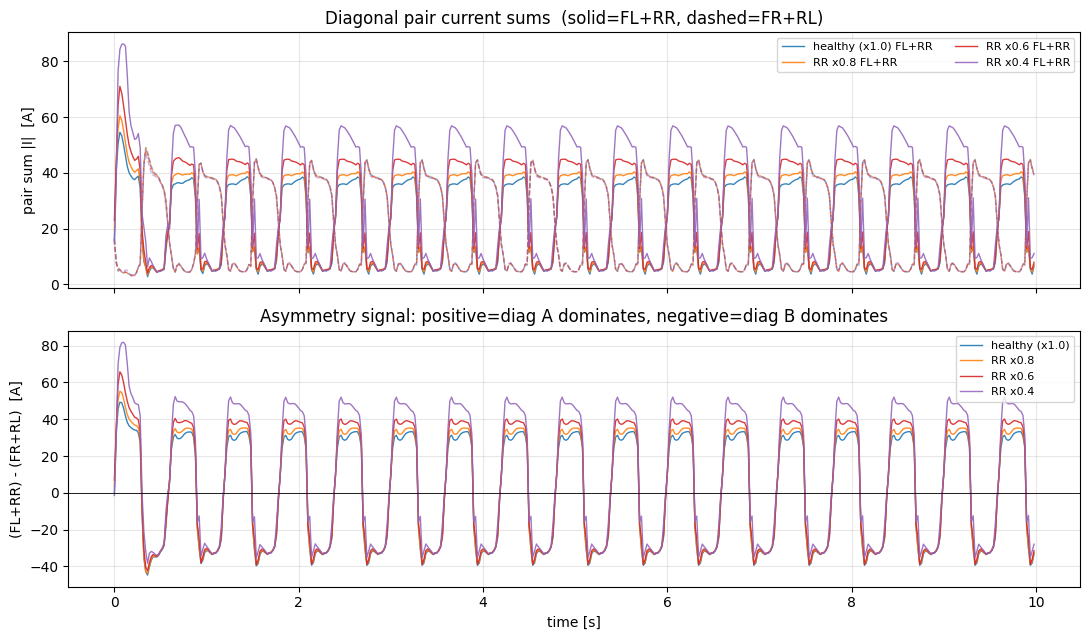

<Figure size 640x480 with 0 Axes>

In [ ]:
TRANSIENT_S = 1.0

CASES_SYM = [
    ("healthy (x1.0)", "./data/aplus_tloop_ki200/healthy.npz", "tab:blue"),
    ("RR x0.8",        "./data/aplus_tloop_ki200/RR_0.8.npz",  "tab:orange"),
    ("RR x0.6",        "./data/aplus_tloop_ki200/RR_0.6.npz",  "tab:red"),
    ("RR x0.4",        "./data/aplus_tloop_ki200/RR_0.4.npz",  "tab:purple"),
]
LEGS           = ["FL", "FR", "RL", "RR"]
JOINTS_PER_LEG = ["hip", "thigh", "calf"]

sample_meta = json.loads(str(np.load(CASES_SYM[0][1], allow_pickle=True)["meta"]))
jnames      = sample_meta["q_all_joint_names"]
leg_cols    = {leg: [jnames.index(f"{leg}_{j}_joint") for j in JOINTS_PER_LEG] for leg in LEGS}

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

print(f"{'case':<16} {'mean FL+RR':>12} {'mean FR+RL':>12} "
      f"{'ratio':>8} {'|ratio-1|':>11}")
print("-" * 65)

for label, path, color in CASES_SYM:
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    t = np.arange(m["num_steps"]) * m["dt"]
    absI = np.abs(d["I_actual"])

    # 쌍별 전류 합 시계열
    pair_A = absI[:, leg_cols["FL"] + leg_cols["RR"]].sum(axis=1)   # 대각 A
    pair_B = absI[:, leg_cols["FR"] + leg_cols["RL"]].sum(axis=1)   # 대각 B

    axes[0].plot(t, pair_A, color=color,      lw=1.0, alpha=0.9, label=f"{label} FL+RR")
    axes[0].plot(t, pair_B, color=color, ls="--", lw=1.0, alpha=0.5)
    axes[1].plot(t, pair_A - pair_B, color=color, lw=1.0, alpha=0.9, label=label)

    # 정상상태 통계
    k0 = int(TRANSIENT_S / m["dt"])
    a = float(pair_A[k0:].mean()); b = float(pair_B[k0:].mean())
    ratio = a / max(b, 1e-9)
    print(f"{label:<16} {a:>11.3f}  {b:>11.3f}  {ratio:>7.3f}  {abs(ratio-1):>10.3f}")

axes[0].set_ylabel("pair sum |I|  [A]")
axes[0].set_title("Diagonal pair current sums  (solid=FL+RR, dashed=FR+RL)")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8, ncol=2)

axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_ylabel("(FL+RR) - (FR+RL)  [A]")
axes[1].set_xlabel("time [s]")
axes[1].set_title("Asymmetry signal: positive=diag A dominates, negative=diag B dominates")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

_apply_time_window()


## (5c) Locomotion 전파 severity 곡선 — "언제부터 숨길 수 없게 되는지"

전기적 pattern 은 이미 뚜렷하지만 로봇은 여전히 걷는다. 그럼 "얼마나 심해져야 locomotion 도 망가지기 시작하나" 를 severity = `1 − demag_factor` 축으로 정리:

- **|vx − 0.5|** (전진속도 추종 오차)
- **|vy|** (측방 드리프트 속도 평균)
- **yaw drift rate** = `(yaw_end − yaw_start) / total_time` (장기 회전 bias)
- **std(roll)**, **std(pitch)** (자세 흔들림 진폭)

각 지표가 severity 에 **선형** 으로 오르면 continuous degradation, 특정 지점에서 **꺾임** 이 있으면 제어 경계. 4 개 다리 (FL/FR/RL/RR) × 3 factor 에서 각 지표 평균을 찍어 패턴 확인.

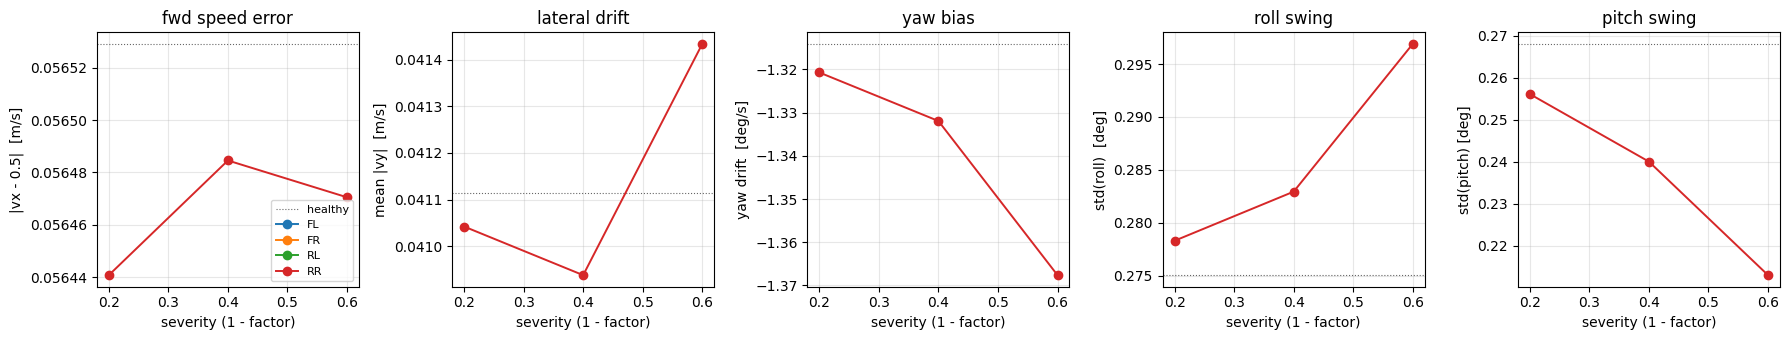


healthy baseline: {'vx_err': 0.05652913823723793, 'vy_mean': 0.04111327603459358, 'yaw_drift': -1.3140764236450195, 'roll_std': 0.27506619691848755, 'pitch_std': 0.26809120178222656}

case            vx_err       vy_mean     yaw_drift      roll_std     pitch_std
------------------------------------------------------------------------------
FLx0.8             nan           nan           nan           nan           nan
FLx0.6             nan           nan           nan           nan           nan
FLx0.4             nan           nan           nan           nan           nan
FRx0.8             nan           nan           nan           nan           nan
FRx0.6             nan           nan           nan           nan           nan
FRx0.4             nan           nan           nan           nan           nan
RLx0.8             nan           nan           nan           nan           nan
RLx0.6             nan           nan           nan           nan           nan
RLx0.4             nan   

<Figure size 640x480 with 0 Axes>

In [ ]:
TRANSIENT_S = 1.0
LEGS        = ["FL", "FR", "RL", "RR"]
FACTORS     = [0.8, 0.6, 0.4]

# (leg, factor) 모든 조합 + healthy
def load_case(path):
    d = np.load(path, allow_pickle=True)
    m = json.loads(str(d["meta"]))
    return d, m

# healthy 기준값
d0, m0 = load_case("./data/aplus_tloop_ki200/healthy.npz")
k0_0   = int(TRANSIENT_S / m0["dt"])
def metrics(d, m):
    k0 = int(TRANSIENT_S / m["dt"])
    vx = d["base_lin_vel"][k0:, 0]
    vy = d["base_lin_vel"][k0:, 1]
    roll  = np.rad2deg(d["base_rpy"][k0:, 0])
    pitch = np.rad2deg(d["base_rpy"][k0:, 1])
    yaw_full = np.rad2deg(d["base_rpy"][:, 2])
    total_s  = m["num_steps"] * m["dt"]
    return {
        "vx_err":     float(np.mean(np.abs(vx - 0.5))),
        "vy_mean":    float(np.mean(np.abs(vy))),
        "yaw_drift":  float((yaw_full[-1] - yaw_full[0]) / total_s),   # deg/s
        "roll_std":   float(np.std(roll)),
        "pitch_std":  float(np.std(pitch)),
    }

base_metrics = metrics(d0, m0)

# leg 당 severity 축 위의 값들 수집
data = {leg: {k: [] for k in ["vx_err", "vy_mean", "yaw_drift", "roll_std", "pitch_std"]}
        for leg in LEGS}
x_sev = [1.0 - f for f in FACTORS]   # severity = 1 - factor, 오름차순으로

for leg in LEGS:
    for f in FACTORS:
        path = f"./data/aplus_tloop_ki200/{leg}_{f}.npz"
        try:
            d, m = load_case(path)
        except FileNotFoundError:
            for k in data[leg]:
                data[leg][k].append(float("nan"))
            continue
        mm = metrics(d, m)
        for k in data[leg]:
            data[leg][k].append(mm[k])

# ── 5 subplot (각 metric) × 4 leg 곡선 ──
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
metric_info = [
    ("vx_err",    "|vx - 0.5|  [m/s]",  "fwd speed error"),
    ("vy_mean",   "mean |vy|  [m/s]",   "lateral drift"),
    ("yaw_drift", "yaw drift  [deg/s]", "yaw bias"),
    ("roll_std",  "std(roll)  [deg]",   "roll swing"),
    ("pitch_std", "std(pitch) [deg]",   "pitch swing"),
]
colors_leg = {"FL": "tab:blue", "FR": "tab:orange", "RL": "tab:green", "RR": "tab:red"}

for ax, (key, ylab, title) in zip(axes, metric_info):
    # healthy 수평 점선
    ax.axhline(base_metrics[key], color="k", lw=0.8, ls=":", alpha=0.6, label="healthy")
    for leg in LEGS:
        ax.plot(x_sev, data[leg][key], marker="o", color=colors_leg[leg], lw=1.4, label=leg)
    ax.set_xlabel("severity (1 - factor)")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="best")
fig.tight_layout()
plt.show()

# 표: 모든 leg · factor · 지표
print(f"\nhealthy baseline: {base_metrics}\n")
hdr = f"{'case':<8}" + "".join(f"{m[0]:>14}" for m in metric_info)
print(hdr); print("-" * len(hdr))
for leg in LEGS:
    for i, f in enumerate(FACTORS):
        tag = f"{leg}x{f}"
        row = f"{tag:<8}" + "".join(f"{data[leg][k][i]:>14.4f}" for k, _, _ in metric_info)
        print(row)

_apply_time_window()
